# **0. INTRODUCTION AND RESEARCH QUESTION**

Momentum is one of the most widely studied equity strategies. A standard cross-sectional momentum strategy ranks stocks according to their past performance and buys recent winners while shorting recent losers. Although this approach is simple and popular, it is also known to have two important weaknesses: exposure to systematic risk factors and vulnerability to momentum crashes.

This project studies whether a plain cross-sectional momentum strategy can be improved by explicitly addressing these two weaknesses. The empirical analysis is based on S&P 500 constituents and monthly data. The baseline strategy is a standard 12–1 cross-sectional momentum portfolio, constructed by ranking stocks on their past returns from month (t-12) to month (t-1).

The main research question is:

**Can a plain cross-sectional momentum strategy be improved by reducing its exposure to systematic risk factors and mitigating momentum crashes?**

To answer this question, I compare the baseline momentum strategy with three refinements:

1. **FF5 residual momentum**, which ranks stocks using returns residualized with respect to the Fama-French 5-factor model;
2. **Volatility-targeted momentum**, which scales the exposure of the plain momentum portfolio according to recent realised volatility;
3. **A combined strategy**, which applies no-leverage volatility targeting to FF5 residual momentum.

The objective is not only to identify the strategy with the highest return, but also to evaluate whether the proposed refinements improve the risk profile of momentum, especially in terms of factor exposure, volatility, drawdowns and extreme losses.


**0.1 Methodology overview**

The empirical analysis follows a step-by-step structure.

First, I perform a data audit and cleaning procedure. The raw dataset contains monthly prices and historical S&P 500 weights. Since some securities appear to have forward-filled prices after leaving the index, the investable universe is not defined using price availability alone. Instead, a stock is considered eligible only when its lagged historical S&P 500 weight is positive. I also check for extreme returns and for multiple securities linked to the same company. These issues are documented as data-quality limitations, but the main backtest is kept at the security level, consistently with the structure of the original dataset.

Second, I reconstruct two benchmarks: a value-weighted benchmark based on lagged historical S&P 500 weights, and an equal-weighted benchmark based on the clean investable universe. The value-weighted benchmark is used as the main benchmark because it is closer to the actual index construction. Its validity is checked by comparing it with the S&P 500 index series contained in the dataset.

Third, I implement the baseline strategy: a plain 12–1 cross-sectional momentum portfolio. Each month, eligible stocks are ranked using their past 12–1 return. The strategy buys the top decile of stocks and shorts the bottom decile, with equal weights within each leg. I also compute a long-only top-decile portfolio as a secondary investor-oriented reference, but the main academic baseline is the long-short portfolio.

Fourth, I construct an FF5 residual momentum strategy. For each stock, I estimate rolling Fama-French 5-factor regressions using excess returns. The residuals from these regressions are used to build a residual momentum signal, defined as the mean of past residuals divided by their standard deviation. The portfolio construction is kept identical to the plain momentum strategy, so that the comparison is driven by the signal rather than by different portfolio rules.

Fifth, I apply volatility targeting to the plain momentum long-short strategy. The exposure is scaled using a trailing 6-month realised volatility estimate, lagged by one month to avoid look-ahead bias. I consider both a standard version with a leverage cap of 2.0 and a no-leverage version with the scaling factor capped at 1.0. The no-leverage version is used as a more conservative crash-protection variant.

Sixth, I construct a combined strategy by applying no-leverage volatility targeting to the FF5 residual momentum portfolio. This strategy is designed to address both weaknesses at the same time: residualisation aims to reduce systematic factor exposure, while volatility targeting aims to mitigate crash risk.

Finally, I compare all strategies over a common sample period using performance metrics, crash-risk measures and factor exposure analysis. The main metrics include annualized mean return, CAGR, annualized volatility, Sharpe ratio, maximum drawdown, worst monthly return and worst 3-month return. I also run Fama-French 5-factor regressions on the strategy returns to evaluate alpha, factor betas and R-squared.


# **1. DATA AUDIT & CLEANING**

**1.1 Load prices, weights and historical membership**

In [1]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

FILE_PATH = "/content/drive/MyDrive/FINANCIAL_MOMENTUM_PROJECT/Data/SPX500 Original.xlsm"

# Read monthly prices and monthly weights.
# The first row contains tickers, the second row contains company names.
prices_raw = pd.read_excel(FILE_PATH, sheet_name="Price", header=[0, 1], index_col=0)
weights_raw = pd.read_excel(FILE_PATH, sheet_name="Peso", header=[0, 1], index_col=0)

# Convert index to datetime.
prices_raw.index = pd.to_datetime(prices_raw.index)
weights_raw.index = pd.to_datetime(weights_raw.index)

# Keep only ticker level as column names.
prices_raw.columns = prices_raw.columns.get_level_values(0)
weights_raw.columns = weights_raw.columns.get_level_values(0)

# Convert possible error strings to NaN and force numeric values.
prices = prices_raw.apply(pd.to_numeric, errors="coerce")
weights = weights_raw.apply(pd.to_numeric, errors="coerce")

# Align prices and weights.
common_dates = prices.index.intersection(weights.index)
common_tickers = prices.columns.intersection(weights.columns)

prices = prices.loc[common_dates, common_tickers].sort_index()
weights = weights.loc[common_dates, common_tickers].sort_index()

# Historical membership: a stock is active if its index weight is positive.
active = weights.notna() & (weights > 0)

print("Price matrix shape:", prices.shape)
print("Weights matrix shape:", weights.shape)
print("Sample period:", prices.index.min(), "to", prices.index.max())
print("Average number of active stocks:", active.sum(axis=1).mean())
print("Min active stocks:", active.sum(axis=1).min())
print("Max active stocks:", active.sum(axis=1).max())
print("Average sum of weights:", weights.sum(axis=1).mean())

Price matrix shape: (336, 1355)
Weights matrix shape: (336, 1355)
Sample period: 1990-12-31 00:00:00 to 2018-11-30 00:00:00
Average number of active stocks: 500.61607142857144
Min active stocks: 498
Max active stocks: 506
Average sum of weights: 100.00000007738096


**1.2 Forward-filled / stale prices audit**

The price sheet contains observations also for securities that were not active S&P 500 constituents in a given month. To check whether these observations may include stale or forward-filled prices, I compute monthly log-returns and compare the frequency of zero returns for active and inactive securities.

A zero log-return means that the price did not change between two consecutive months. A materially higher fraction of zero returns among inactive stocks would suggest the presence of stale or forward-filled prices after index exit.

In [3]:
STALE_THRESHOLD_MONTHS = 6
ZERO_RETURN_TOL = 1e-12

# Raw monthly log-returns.
log_returns_raw = np.log(prices / prices.shift(1))

# A zero log-return means that the price did not change
# between two consecutive months.
zero_returns = log_returns_raw.abs() < ZERO_RETURN_TOL

# Active/inactive status in both current and previous month.
active_previous = active.shift(1).fillna(False).astype(bool)

active_both_months = active & active_previous
inactive_both_months = (~active) & (~active_previous)

audit_table = pd.DataFrame({
    "valid_log_returns": [
        log_returns_raw.notna().sum().sum(),
        log_returns_raw.where(active_both_months).notna().sum().sum(),
        log_returns_raw.where(inactive_both_months).notna().sum().sum()
    ],
    "zero_log_returns": [
        zero_returns.where(log_returns_raw.notna()).sum().sum(),
        zero_returns.where(active_both_months & log_returns_raw.notna()).sum().sum(),
        zero_returns.where(inactive_both_months & log_returns_raw.notna()).sum().sum()
    ]
}, index=[
    "All available prices",
    "Active index members",
    "Inactive stocks"
])

audit_table["zero_return_ratio"] = (
    audit_table["zero_log_returns"] / audit_table["valid_log_returns"]
)

audit_table

,valid_log_returns,zero_log_returns,zero_return_ratio
All available prices,387933,107223,0.276396
Active index members,166829,1297,0.007774
Inactive stocks,219465,105808,0.482118


**1.2.1 Identifying post-exit stale prices**

To provide a more concrete diagnostic, I also identify stocks with suspected stale prices after index exit. A stock is flagged if, after its last active month in the S&P 500, it displays at least six consecutive months of zero log-returns. This flag is used only for data inspection, not as the main cleaning rule.

In [4]:
def identify_post_exit_stale_prices(prices, active, min_consecutive_months=6, tol=1e-12):
    """
    Identify stocks with suspected stale / forward-filled prices after index exit.

    A stock is flagged if, after its last active month in the index,
    it has at least `min_consecutive_months` consecutive months of zero log-returns.
    """
    log_returns = np.log(prices / prices.shift(1))
    records = []

    for ticker in prices.columns:
        active_series = active[ticker].fillna(False).astype(bool)

        if not active_series.any():
            continue

        last_active_date = active_series[active_series].index.max()
        post_exit_dates = prices.index[prices.index > last_active_date]

        if len(post_exit_dates) == 0:
            continue

        zero_post_exit = (
            (log_returns.loc[post_exit_dates, ticker].abs() < tol)
            & prices.loc[post_exit_dates, ticker].notna()
            & prices.shift(1).loc[post_exit_dates, ticker].notna()
            & (~active.loc[post_exit_dates, ticker].fillna(False).astype(bool))
        )

        current_run = 0
        max_run = 0
        run_start = None
        best_start = None
        best_end = None

        for date, is_zero in zero_post_exit.items():
            if is_zero:
                if current_run == 0:
                    run_start = date

                current_run += 1

                if current_run > max_run:
                    max_run = current_run
                    best_start = run_start
                    best_end = date
            else:
                current_run = 0
                run_start = None

        if max_run >= min_consecutive_months:
            records.append({
                "ticker": ticker,
                "last_active_date": last_active_date,
                "max_consecutive_zero_returns_after_exit": max_run,
                "stale_sequence_start": best_start,
                "stale_sequence_end": best_end
            })

    post_exit_stale_prices = pd.DataFrame(records)

    if len(post_exit_stale_prices) > 0:
        post_exit_stale_prices = post_exit_stale_prices.sort_values(
            "max_consecutive_zero_returns_after_exit",
            ascending=False
        )

    return post_exit_stale_prices


post_exit_stale_prices = identify_post_exit_stale_prices(
    prices=prices,
    active=active,
    min_consecutive_months=STALE_THRESHOLD_MONTHS,
    tol=ZERO_RETURN_TOL
)

print("Number of stocks with suspected post-exit stale prices:",
      len(post_exit_stale_prices))

post_exit_stale_prices.head(10)

Number of stocks with suspected post-exit stale prices: 663


,ticker,last_active_date,max_consecutive_zero_returns_after_exit,stale_sequence_start,stale_sequence_end
252,3123863Q UN Equity,1991-04-30,330,1991-06-28,2018-11-30
279,643319Q UN Equity,1991-04-30,328,1991-08-30,2018-11-30
192,1503Q UN Equity,1991-08-30,326,1991-10-31,2018-11-30
82,1708Q US Equity,1991-10-31,325,1991-11-29,2018-11-30
136,HBJ UN Equity,1991-10-31,325,1991-11-29,2018-11-30
48,601964Q US Equity,1991-12-31,323,1992-01-31,2018-11-30
169,292356Z US Equity,1991-12-31,323,1992-01-31,2018-11-30
256,BAC1 US Equity,1992-03-31,319,1992-05-29,2018-11-30
10,AZA UA Equity,1992-05-29,318,1992-06-30,2018-11-30
210,1684442D UA Equity,1992-09-30,313,1992-11-30,2018-11-30


The audit identifies 663 stocks with suspected post-exit stale prices, defined as stocks displaying at least six consecutive months of zero log-returns after their last active month in the S&P 500. Several securities show very long sequences of unchanged prices after index exit, sometimes extending until the end of the sample.

This confirms that price availability alone is not a reliable definition of the investable universe. Therefore, the stale-price flag is used only as diagnostic evidence. The actual backtest relies on the historical weights sheet: a stock is eligible only when its lagged S&P 500 weight is positive.

**1.3 Multiple securities linked to the same company**

As an additional data-quality check, I investigate whether the dataset contains multiple securities associated with the same company. This may happen because of share classes, ticker changes, mergers, spin-offs or historical Bloomberg identifiers.

This issue is relevant because the momentum portfolios are equal-weighted at the security level. If multiple securities from the same company are simultaneously active, the portfolio could unintentionally give more economic weight to the same company.

In [5]:
import re

def normalize_company_name(name):
    """
    Conservative company-name normalization for duplicate-security audit.
    This is only an approximate diagnostic, not a definitive issuer identifier.
    """
    if pd.isna(name):
        return np.nan

    name = str(name).upper().strip()
    name = re.sub(r"[^A-Z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    suffixes = [
        " INC", " CORP", " CORPORATION", " CO", " COMPANY",
        " LTD", " PLC", " SA", " NV", " LP", " LLC"
    ]

    for suffix in suffixes:
        if name.endswith(suffix):
            name = name[: -len(suffix)].strip()

    return name


# Re-read the weights sheet only for audit purposes.
# This does not overwrite the main project variables.
duplicate_audit_weights_raw = pd.read_excel(
    FILE_PATH,
    sheet_name="Peso",
    header=[0, 1],
    index_col=0
)

duplicate_audit_weights_raw.index = pd.to_datetime(
    duplicate_audit_weights_raw.index
)

duplicate_audit_tickers = duplicate_audit_weights_raw.columns.get_level_values(0)
duplicate_audit_company_names = duplicate_audit_weights_raw.columns.get_level_values(1)

duplicate_security_map = pd.DataFrame({
    "ticker": duplicate_audit_tickers,
    "company_name": duplicate_audit_company_names
})

duplicate_security_map["company_name_normalized"] = (
    duplicate_security_map["company_name"]
    .apply(normalize_company_name)
)

duplicate_security_map = duplicate_security_map[
    duplicate_security_map["company_name_normalized"].notna()
].copy()

duplicate_security_map = duplicate_security_map[
    ~duplicate_security_map["company_name_normalized"].str.contains(
        "UNNAMED",
        na=False
    )
].copy()

# Historical duplicate check:
# companies associated with more than one ticker somewhere in the dataset.
historical_duplicate_companies = (
    duplicate_security_map
    .groupby("company_name_normalized")["ticker"]
    .nunique()
    .sort_values(ascending=False)
)

historical_duplicate_companies = historical_duplicate_companies[
    historical_duplicate_companies > 1
]

print("Number of normalized companies with more than one ticker historically:",
      len(historical_duplicate_companies))

historical_duplicate_companies.head(10)

Number of normalized companies with more than one ticker historically: 170


,ticker
company_name_normalized,
COMCAST,4
NORDSTROM,3
KOMATSU MINING,3
ADVANCED MICRO DEVICES,3
MATTEL,3
HASBRO,3
SAFECO,3
BROADCOM,3
BMC SOFTWARE,3


In [6]:
duplicate_company_norm = [
    normalize_company_name(name)
    for name in duplicate_audit_weights_raw.columns.get_level_values(1)
]

duplicate_ticker_level = duplicate_audit_weights_raw.columns.get_level_values(0)

duplicate_audit_weights = duplicate_audit_weights_raw.copy()
duplicate_audit_weights.columns = pd.MultiIndex.from_arrays(
    [duplicate_ticker_level, duplicate_company_norm],
    names=["ticker", "company_name_normalized"]
)

duplicate_audit_weights = duplicate_audit_weights.apply(
    pd.to_numeric,
    errors="coerce"
)

duplicate_audit_active = (
    duplicate_audit_weights.notna()
    & (duplicate_audit_weights > 0)
)

duplicate_active_count_by_company = (
    duplicate_audit_active
    .T
    .groupby(level="company_name_normalized")
    .sum()
    .T
)

duplicate_active_count_by_company = duplicate_active_count_by_company.loc[
    :,
    duplicate_active_count_by_company.columns.notna()
]

duplicate_active_count_by_company = duplicate_active_count_by_company.loc[
    :,
    ~duplicate_active_count_by_company.columns.astype(str).str.contains(
        "UNNAMED",
        na=False
    )
]

simultaneous_duplicate_mask = duplicate_active_count_by_company > 1

n_months_with_any_simultaneous_duplicate = int(
    simultaneous_duplicate_mask.any(axis=1).sum()
)

n_company_months_with_simultaneous_duplicates = int(
    simultaneous_duplicate_mask.sum().sum()
)

companies_with_simultaneous_duplicates = (
    simultaneous_duplicate_mask
    .sum(axis=0)
    .sort_values(ascending=False)
)

companies_with_simultaneous_duplicates = companies_with_simultaneous_duplicates[
    companies_with_simultaneous_duplicates > 0
]

print("Months with at least one simultaneous company duplicate:",
      n_months_with_any_simultaneous_duplicate)

print("Company-month duplicate observations:",
      n_company_months_with_simultaneous_duplicates)

print("Companies with simultaneous duplicate active securities:",
      len(companies_with_simultaneous_duplicates))

companies_with_simultaneous_duplicates.head(10)

Months with at least one simultaneous company duplicate: 251
Company-month duplicate observations: 572
Companies with simultaneous duplicate active securities: 10


,0
company_name_normalized,
AT T,179
FREEPORT MCMORAN,140
ALPHABET,56
DISCOVERY,52
TWENTY FIRST CENTURY FOX,39
NEWS,39
UNDER ARMOUR,32
BROADCOM,21
UNUM GROUP,11


In [7]:
duplicate_detail_records = []

for company in companies_with_simultaneous_duplicates.index:
    duplicate_dates = duplicate_active_count_by_company.index[
        duplicate_active_count_by_company[company] > 1
    ]

    max_active_count = int(
        duplicate_active_count_by_company.loc[duplicate_dates, company].max()
    )

    representative_date = duplicate_active_count_by_company.loc[
        duplicate_dates, company
    ].idxmax()

    company_columns = [
        col for col in duplicate_audit_active.columns
        if col[1] == company
    ]

    active_tickers_on_representative_date = (
        duplicate_audit_active
        .loc[representative_date, company_columns]
    )

    active_tickers_on_representative_date = [
        ticker for ticker, is_active in active_tickers_on_representative_date.items()
        if bool(is_active)
    ]

    duplicate_detail_records.append({
        "company_name_normalized": company,
        "months_with_simultaneous_duplicates": int(len(duplicate_dates)),
        "first_duplicate_month": duplicate_dates.min(),
        "last_duplicate_month": duplicate_dates.max(),
        "max_simultaneous_active_securities": max_active_count,
        "representative_month": representative_date,
        "active_tickers_in_representative_month": active_tickers_on_representative_date
    })

simultaneous_duplicate_detail = (
    pd.DataFrame(duplicate_detail_records)
    .sort_values(
        ["months_with_simultaneous_duplicates", "max_simultaneous_active_securities"],
        ascending=False
    )
)

simultaneous_duplicate_detail.head(10)

,company_name_normalized,months_with_simultaneous_duplicates,first_duplicate_month,last_duplicate_month,max_simultaneous_active_securities,representative_month,active_tickers_in_representative_month
0,AT T,179,1990-12-31,2005-10-31,2,1990-12-31,"[(653707Q UN Equity, AT T), (T UN Equity, AT T)]"
1,FREEPORT MCMORAN,140,1995-07-31,2007-02-28,2,1995-07-31,"[(PD UN Equity, FREEPORT MCMORAN), (FCX UN Equ..."
2,ALPHABET,56,2014-04-30,2018-11-30,2,2014-04-30,"[(GOOGL UW Equity, ALPHABET), (GOOG UW Equity,..."
3,DISCOVERY,52,2014-08-29,2018-11-30,2,2014-08-29,"[(DISCA UW Equity, DISCOVERY), (DISCK UW Equit..."
4,TWENTY FIRST CENTURY FOX,39,2015-09-30,2018-11-30,2,2015-09-30,"[(FOXA UW Equity, TWENTY FIRST CENTURY FOX), (..."
5,NEWS,39,2015-09-30,2018-11-30,2,2015-09-30,"[(NWSA UW Equity, NEWS), (NWS UW Equity, NEWS)]"
6,UNDER ARMOUR,32,2016-04-29,2018-11-30,2,2016-04-29,"[(UAA UN Equity, UNDER ARMOUR), (UA UN Equity,..."
7,BROADCOM,21,2014-05-30,2016-01-29,2,2014-05-30,"[(BRCM UW Equity, BROADCOM), (AVGO UW Equity, ..."
8,UNUM GROUP,11,1998-08-31,1999-06-30,2,1998-08-31,"[(UNM UN Equity, UNUM GROUP), (PVT UN Equity, ..."
9,COMCAST,3,2015-09-30,2015-11-30,2,2015-09-30,"[(CMCSA UW Equity, COMCAST), (CMCSK UW Equity,..."


The audit identifies 170 normalized company names associated with more than one ticker historically. This historical count is not necessarily problematic, because it may reflect ticker changes, corporate events or different share classes.

The more relevant issue is whether multiple securities linked to the same company are simultaneously active in the investable universe. This occurs for 10 companies, corresponding to 572 company-month duplicate observations. The maximum number of simultaneous active securities for the same normalized company is two.

Several cases appear to be related to legitimate share-class structures or corporate events, such as Alphabet, Discovery, News, Under Armour, Comcast and Twenty First Century Fox. Since the dataset is structured at the security level and the historical weights sheet assigns positive weights to these securities, I keep the main backtest at the security level.

This issue is reported as a data limitation rather than corrected through an additional filtering rule, because selecting one security per company or aggregating securities would require further assumptions and could introduce arbitrary choices.

**1.4 Extreme return audit**

After filtering the investable universe using historical membership, I also inspect extreme monthly returns. This step is useful because very large positive or negative returns may be related to genuine market events, but may also reflect corporate actions, share-class changes, stale prices or isolated data issues.

At this stage, extreme returns are not removed automatically. They are only flagged for inspection. This avoids deleting economically meaningful crashes, which are especially relevant for a momentum crash analysis.

In [8]:
# Raw monthly returns from prices.
returns_raw = prices.pct_change()

# Lagged membership used for portfolio returns.
# A stock is tradable at month t only if it was active in the index at t-1.
active_lagged = active.shift(1, fill_value=False).astype(bool)

# Clean return matrix restricted to the investable universe.
returns_clean = returns_raw.where(active_lagged)

print("Raw return observations:", returns_raw.notna().sum().sum())
print("Clean return observations:", returns_clean.notna().sum().sum())
print("First clean return date:", returns_clean.dropna(how="all").index.min())
print("Last clean return date:", returns_clean.dropna(how="all").index.max())

Raw return observations: 387933
Clean return observations: 167702
First clean return date: 1991-01-31 00:00:00
Last clean return date: 2018-11-30 00:00:00


In [9]:
# Extreme return thresholds.
EXTREME_NEGATIVE_RETURN = -0.90
EXTREME_POSITIVE_RETURN = 1.00

# Identify extreme returns within the clean investable universe.
extreme_returns = (
    (returns_clean < EXTREME_NEGATIVE_RETURN) |
    (returns_clean > EXTREME_POSITIVE_RETURN)
)

extreme_return_count = int(extreme_returns.sum().sum())
total_clean_returns = int(returns_clean.notna().sum().sum())

print("Number of extreme clean returns:", extreme_return_count)
print("Total clean return observations:", total_clean_returns)
print("Extreme return ratio:", round(extreme_return_count / total_clean_returns, 6))

# Build a table with the most extreme observations.
extreme_return_records = []

for date in returns_clean.index:
    tickers = returns_clean.columns[extreme_returns.loc[date].fillna(False)]

    for ticker in tickers:
        extreme_return_records.append({
            "date": date,
            "ticker": ticker,
            "return": returns_clean.loc[date, ticker],
            "price_t": prices.loc[date, ticker],
            "price_t_minus_1": prices.shift(1).loc[date, ticker],
            "active_t_minus_1": active_lagged.loc[date, ticker],
            "active_t": active.loc[date, ticker]
        })

extreme_return_table = pd.DataFrame(extreme_return_records)

if len(extreme_return_table) > 0:
    extreme_return_table["abs_return"] = extreme_return_table["return"].abs()
    extreme_return_table = extreme_return_table.sort_values(
        "abs_return",
        ascending=False
    )

extreme_return_table.head(10)

Number of extreme clean returns: 21
Total clean return observations: 167702
Extreme return ratio: 0.000125


,date,ticker,return,price_t,price_t_minus_1,active_t_minus_1,active_t,abs_return
15,2008-12-31,8394653Q UN Equity,2.626632,13.8900,3.8300,True,True,2.626632
20,2009-08-31,AIG UN Equity,2.449775,37.9734,11.0075,True,True,2.449775
1,1991-01-31,USG UN Equity,1.923080,91.9405,31.4533,True,True,1.923080
18,2009-04-30,WYND UN Equity,1.780955,5.2713,1.8955,True,True,1.780955
14,2008-08-29,MBI UN Equity,1.735245,16.2200,5.9300,True,True,1.735245
7,2002-08-30,0772031D UN Equity,1.539062,3.2500,1.2800,True,True,1.539062
19,2009-05-29,GNW UN Equity,1.508475,5.9200,2.3600,True,True,1.508475
9,2002-11-29,SEE UN Equity,1.468016,18.9050,7.6600,True,True,1.468016
16,2009-03-31,AIG UN Equity,1.380940,16.7542,7.0368,True,True,1.380940
8,2002-11-29,GLW UN Equity,1.368984,4.4300,1.8700,True,True,1.368984


**1.5 Clean return matrix and momentum eligibility**


Monthly simple returns are first computed from raw prices. However, a return is retained only if the stock was an active S&P 500 constituent in the previous month. This reflects the investable universe available at portfolio formation.

The plain momentum signal is computed as a 12–1 price momentum signal. To avoid using stale or non-investable price histories, a stock is eligible for ranking only if it was active during the full lookback window used to compute the signal.

In [10]:
# Plain 12-1 momentum signal:
# signal at month t uses P_{t-1} / P_{t-12} - 1.
momentum_signal_raw = prices.shift(1) / prices.shift(12) - 1

# A stock is eligible for the momentum ranking only if it was active
# during the full lookback window used to compute the 12-1 signal.
lookback_active = (
    active.shift(1)
    .rolling(window=12, min_periods=12)
    .sum()
    .eq(12)
)

momentum_signal_clean = momentum_signal_raw.where(lookback_active)

print("Raw return observations:", returns_raw.notna().sum().sum())
print("Clean return observations:", returns_clean.notna().sum().sum())
print("Raw momentum signals:", momentum_signal_raw.notna().sum().sum())
print("Clean momentum signals:", momentum_signal_clean.notna().sum().sum())

print("First available clean return date:", returns_clean.dropna(how="all").index.min())
print("Last available clean return date:", returns_clean.dropna(how="all").index.max())
print("First available clean momentum signal date:", momentum_signal_clean.dropna(how="all").index.min())

Raw return observations: 387933
Clean return observations: 167702
Raw momentum signals: 373040
Clean momentum signals: 152950
First available clean return date: 1991-01-31 00:00:00
Last available clean return date: 2018-11-30 00:00:00
First available clean momentum signal date: 1991-12-31 00:00:00


The extreme return audit identifies only 21 observations with monthly returns below -90% or above +100%, corresponding to approximately 0.0125% of the clean return observations. These observations occur while the stocks are active S&P 500 constituents, so they do not appear to be driven by the stale-price issue documented above.

For this reason, extreme returns are not removed or winsorized in the main analysis. This is a conservative choice because some extreme returns may reflect genuine market events, especially during crisis periods, and are relevant for evaluating momentum crash risk.

**1.6 Benchmark construction and validation**

**1.6.1 Benchmark construction**

The main benchmark is a value-weighted S&P 500 benchmark reconstructed from the historical weights sheet. To avoid look-ahead bias, weights are lagged by one month. For month \(t\), the benchmark uses the index weights observed at \(t-1\) and the stock returns realised in month \(t\).

An equal-weighted benchmark is also computed as a secondary reference, using the same clean investable universe. The value-weighted benchmark is the main benchmark because it is closer to the actual S&P 500 index construction.

In [11]:
# Lagged membership used for portfolio formation.
active_lagged = active.shift(1, fill_value=False).astype(bool)

# Lagged index weights.
# Weights are expressed in percentage terms in the dataset, so they are normalized.
weights_lagged = weights.shift(1)

# Use only stocks that were active at t-1 and have an available return at t.
benchmark_weight_base = weights_lagged.where(
    active_lagged & returns_raw.notna()
)

# Normalize weights to sum to 1 each month among available constituents.
benchmark_weights = benchmark_weight_base.div(
    benchmark_weight_base.sum(axis=1),
    axis=0
)

# Value-weighted benchmark based on historical lagged S&P 500 weights.
benchmark_vw = (returns_raw * benchmark_weights).sum(axis=1, min_count=1)
benchmark_vw.name = "Benchmark_ValueWeighted"

# Equal-weighted benchmark based on the same clean investable universe.
benchmark_ew = returns_clean.mean(axis=1, skipna=True)
benchmark_ew.name = "Benchmark_EqualWeighted"

benchmark_returns = pd.concat(
    [benchmark_vw, benchmark_ew],
    axis=1
)

benchmark_returns = benchmark_returns.dropna(how="all")

print("Benchmark sample period:",
      benchmark_returns.index.min(),
      "to",
      benchmark_returns.index.max())

print("Benchmark observations:")
print(benchmark_returns.notna().sum())

benchmark_returns.head()

Benchmark sample period: 1991-01-31 00:00:00 to 2018-11-30 00:00:00
Benchmark observations:
Benchmark_ValueWeighted    335
Benchmark_EqualWeighted    335
dtype: int64


,Benchmark_ValueWeighted,Benchmark_EqualWeighted
1991-01-31,0.041988,0.080372
1991-02-28,0.066856,0.079808
1991-03-29,0.022402,0.028803
1991-04-30,0.000321,0.000705
1991-05-31,0.037784,0.050987


These results suggest that the benchmark is correctly built.
The sample period is coherent and we have 335 monthly observation for both the value-weighted and the equal-weighted benchmarks.

**1.6.2 Benchmark validation against S&P 500 index**

As a validation check, the reconstructed value-weighted benchmark is compared with the S&P 500 index series contained in the `AC` sheet. A very high correlation and a small tracking error would indicate that the historical weights, prices and returns are correctly aligned.

In [12]:
# The AC sheet contains daily, monthly and weekly S&P 500 index levels.
# Columns 2 and 3 contain monthly dates and monthly index levels.

spx_index_raw = pd.read_excel(
    FILE_PATH,
    sheet_name="AC",
    header=None
)

spx_monthly = spx_index_raw.iloc[1:, 2:4].copy()
spx_monthly.columns = ["date", "spx_index"]

spx_monthly["date"] = pd.to_datetime(spx_monthly["date"])
spx_monthly["spx_index"] = pd.to_numeric(
    spx_monthly["spx_index"],
    errors="coerce"
)

spx_monthly = (
    spx_monthly
    .dropna()
    .set_index("date")
    .sort_index()
)

spx_return = spx_monthly["spx_index"].pct_change()
spx_return.name = "SPX_Index_Return"

benchmark_validation = pd.concat(
    [benchmark_vw, spx_return],
    axis=1
).dropna()

benchmark_correlation = benchmark_validation.corr().iloc[0, 1]

benchmark_tracking_error = (
    benchmark_validation["Benchmark_ValueWeighted"]
    - benchmark_validation["SPX_Index_Return"]
).std() * np.sqrt(12)

print("Correlation between constructed value-weighted benchmark and SPX index return:",
      round(benchmark_correlation, 6))

print("Annualized tracking error:",
      round(benchmark_tracking_error, 6))

benchmark_validation.head()

Correlation between constructed value-weighted benchmark and SPX index return: 0.999927
Annualized tracking error: 0.001725


,Benchmark_ValueWeighted,SPX_Index_Return
1991-01-31,0.041988,0.041518
1991-02-28,0.066856,0.067281
1991-03-29,0.022402,0.022203
1991-04-30,0.000321,0.000346
1991-05-31,0.037784,0.038577


These results strongly confirm that the value-weighted benchmark built with historical weights is coherent with the S&P 500 time series shown on the AC sheet of the original dataset.  

# **2. PLAIN CROSS-SECTIONAL MOMENTUM BASELINE**

**2.1.1 *12-1*  MOMENTUM BASELINE**

In [13]:
MOMENTUM_QUANTILE = 0.10
MIN_STOCKS_FOR_RANKING = 30

def build_cross_sectional_momentum_portfolio(
    returns,
    signal,
    quantile=0.10,
    min_stocks=30,
    long_short_name="Plain_Momentum_LongShort",
    long_only_name="Plain_Momentum_LongOnly",
    short_leg_name="Plain_Momentum_ShortLeg"
):
    """
    Build equal-weighted cross-sectional momentum portfolios.

    For each month:
    - rank eligible stocks using the momentum signal;
    - go long the top quantile;
    - go short the bottom quantile;
    - compute long-short return as long leg minus short leg.
    """
    portfolio_records = []

    common_dates = returns.index.intersection(signal.index)
    common_tickers = returns.columns.intersection(signal.columns)

    returns = returns.loc[common_dates, common_tickers]
    signal = signal.loc[common_dates, common_tickers]

    for date in common_dates:
        signal_t = signal.loc[date]
        returns_t = returns.loc[date]

        available = signal_t.dropna().index.intersection(
            returns_t.dropna().index
        )

        if len(available) < min_stocks:
            portfolio_records.append({
                "date": date,
                long_short_name: np.nan,
                long_only_name: np.nan,
                short_leg_name: np.nan,
                "n_available": len(available),
                "n_long": 0,
                "n_short": 0
            })
            continue

        signal_available = signal_t.loc[available]
        returns_available = returns_t.loc[available]

        lower_cutoff = signal_available.quantile(quantile)
        upper_cutoff = signal_available.quantile(1 - quantile)

        short_tickers = signal_available[
            signal_available <= lower_cutoff
        ].index

        long_tickers = signal_available[
            signal_available >= upper_cutoff
        ].index

        long_return = returns_available.loc[long_tickers].mean()
        short_return = returns_available.loc[short_tickers].mean()
        long_short_return = long_return - short_return

        portfolio_records.append({
            "date": date,
            long_short_name: long_short_return,
            long_only_name: long_return,
            short_leg_name: short_return,
            "n_available": len(available),
            "n_long": len(long_tickers),
            "n_short": len(short_tickers)
        })

    portfolio_returns = (
        pd.DataFrame(portfolio_records)
        .set_index("date")
        .sort_index()
    )

    return portfolio_returns


plain_momentum_returns = build_cross_sectional_momentum_portfolio(
    returns=returns_clean,
    signal=momentum_signal_clean,
    quantile=MOMENTUM_QUANTILE,
    min_stocks=MIN_STOCKS_FOR_RANKING,
    long_short_name="Plain_Momentum_LongShort",
    long_only_name="Plain_Momentum_LongOnly",
    short_leg_name="Plain_Momentum_ShortLeg"
)

print("Plain momentum sample period:",
      plain_momentum_returns.dropna(subset=["Plain_Momentum_LongShort"]).index.min(),
      "to",
      plain_momentum_returns.dropna(subset=["Plain_Momentum_LongShort"]).index.max())

print("Number of valid long-short observations:",
      plain_momentum_returns["Plain_Momentum_LongShort"].notna().sum())

plain_momentum_returns.head(10)

Plain momentum sample period: 1991-12-31 00:00:00 to 2018-11-30 00:00:00
Number of valid long-short observations: 324


,Plain_Momentum_LongShort,Plain_Momentum_LongOnly,Plain_Momentum_ShortLeg,n_available,n_long,n_short
date,,,,,,
1990-12-31,NaN,NaN,NaN,0,0,0
1991-01-31,NaN,NaN,NaN,0,0,0
1991-02-28,NaN,NaN,NaN,0,0,0
1991-03-29,NaN,NaN,NaN,0,0,0
1991-04-30,NaN,NaN,NaN,0,0,0
1991-05-31,NaN,NaN,NaN,0,0,0
1991-06-28,NaN,NaN,NaN,0,0,0
1991-07-31,NaN,NaN,NaN,0,0,0
1991-08-30,NaN,NaN,NaN,0,0,0


**2.2 Long-short and long-only portfolios**

In [14]:
baseline_comparison_returns = pd.concat(
    [
        benchmark_returns["Benchmark_ValueWeighted"],
        benchmark_returns["Benchmark_EqualWeighted"],
        plain_momentum_returns["Plain_Momentum_LongShort"],
        plain_momentum_returns["Plain_Momentum_LongOnly"]
    ],
    axis=1
).dropna()

baseline_wealth = (1 + baseline_comparison_returns).cumprod()

print("Baseline comparison sample period:",
      baseline_comparison_returns.index.min(),
      "to",
      baseline_comparison_returns.index.max())

print("Number of observations:",
      len(baseline_comparison_returns))

baseline_comparison_returns.head()

Baseline comparison sample period: 1991-12-31 00:00:00 to 2018-11-30 00:00:00
Number of observations: 324


,Benchmark_ValueWeighted,Benchmark_EqualWeighted,Plain_Momentum_LongShort,Plain_Momentum_LongOnly
1991-12-31,0.111386,0.111562,0.074801,0.145810
1992-01-31,-0.019710,0.016690,-0.049519,0.007418
1992-02-28,0.009714,0.026754,0.005741,0.041710
1992-03-31,-0.021778,-0.022284,0.000973,-0.024484
1992-04-30,0.028061,0.015883,-0.073524,-0.021192


**2.3 Baseline sanity checks**

In [15]:
def compute_drawdown(return_series):
    wealth = (1 + return_series).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown


def compute_performance_summary(returns_df, benchmark_column="Benchmark_ValueWeighted"):
    records = []

    for column in returns_df.columns:
        r = returns_df[column].dropna()

        annualized_mean_return = r.mean() * 12
        cagr = (1 + r).prod() ** (12 / len(r)) - 1
        annualized_volatility = r.std() * np.sqrt(12)

        if annualized_volatility == 0:
            sharpe_ratio = np.nan
        else:
            sharpe_ratio = annualized_mean_return / annualized_volatility

        max_drawdown = compute_drawdown(r).min()
        worst_month = r.min()

        if benchmark_column in returns_df.columns and column != benchmark_column:
            correlation_with_benchmark = r.corr(
                returns_df.loc[r.index, benchmark_column]
            )
        else:
            correlation_with_benchmark = np.nan

        records.append({
            "Strategy": column,
            "Annualized Mean Return": annualized_mean_return,
            "CAGR": cagr,
            "Annualized Volatility": annualized_volatility,
            "Sharpe Ratio": sharpe_ratio,
            "Max Drawdown": max_drawdown,
            "Worst Month": worst_month,
            "Correlation with Benchmark": correlation_with_benchmark
        })

    return pd.DataFrame(records).set_index("Strategy")


baseline_performance_summary = compute_performance_summary(
    baseline_comparison_returns,
    benchmark_column="Benchmark_ValueWeighted"
)

baseline_performance_summary

,Annualized Mean Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Worst Month,Correlation with Benchmark
Strategy,,,,,,,
Benchmark_ValueWeighted,0.083805,0.076487,0.139817,0.599393,-0.524249,-0.169311,NaN
Benchmark_EqualWeighted,0.104673,0.096238,0.157001,0.666702,-0.573088,-0.210142,0.942621
Plain_Momentum_LongShort,0.029140,-0.017528,0.286187,0.101821,-0.824713,-0.473027,-0.375184
Plain_Momentum_LongOnly,0.141009,0.134083,0.170874,0.825221,-0.483323,-0.153377,0.766031


The preliminary results show that the long-only momentum portfolio strongly outperforms the benchmark in cumulative terms. However, this portfolio is not market-neutral: it combines equity market exposure, equal-weighting effects and momentum exposure. For this reason, it is reported only as a secondary investor-oriented reference.

The academic baseline is the long-short momentum portfolio. In this sample, the plain long-short strategy displays weak compounded performance, high volatility and a very large maximum drawdown. This suggests that the baseline momentum strategy is exposed to substantial crash risk, motivating the residual momentum and volatility-targeting refinements.

# **3. FAMA - FRENCH 5 FACTOR MODEL RESIDUAL MOMENTUM**

**3.1 Load and align Fama-French 5 factors**

In [16]:
try:
    import pandas_datareader.data as web
except ImportError:
    !pip install pandas_datareader
    import pandas_datareader.data as web

# Explicitly set the Fama-French download period.
# This is necessary because the default download may return only recent data,
# while our S&P 500 sample ends in 2018.
FF5_START_DATE = returns_clean.dropna(how="all").index.min()
FF5_END_DATE = returns_clean.dropna(how="all").index.max()

ff5_raw = web.DataReader(
    "F-F_Research_Data_5_Factors_2x3",
    "famafrench",
    start=FF5_START_DATE,
    end=FF5_END_DATE
)[0]

ff5_factors = ff5_raw.copy()

# Convert index to monthly PeriodIndex.
# This avoids problems caused by different month-end conventions.
if isinstance(ff5_factors.index, pd.PeriodIndex):
    ff5_factors.index = ff5_factors.index.asfreq("M")
else:
    ff5_factors.index = pd.to_datetime(ff5_factors.index).to_period("M")

# Convert from percentages to decimal returns.
ff5_factors = ff5_factors / 100

# Rename market factor.
ff5_factors = ff5_factors.rename(columns={
    "Mkt-RF": "MKT_RF"
})

ff5_factor_columns = ["MKT_RF", "SMB", "HML", "RMW", "CMA"]

print("Requested FF5 period:",
      FF5_START_DATE,
      "to",
      FF5_END_DATE)

print("FF5 factors sample period:",
      ff5_factors.index.min(),
      "to",
      ff5_factors.index.max())

print("FF5 factor observations:", len(ff5_factors))

ff5_factors.head()

Requested FF5 period: 1991-01-31 00:00:00 to 2018-11-30 00:00:00
FF5 factors sample period: 1991-01 to 2018-11
FF5 factor observations: 335


,MKT_RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1991-01,0.0469,0.0387,-0.0148,0.0134,-0.0407,0.0052
1991-02,0.0721,0.0402,-0.0062,-0.0006,-0.0034,0.0048
1991-03,0.0267,0.0381,-0.0130,-0.0052,-0.0099,0.0044
1991-04,-0.0029,0.0035,0.0149,0.0067,0.0081,0.0053
1991-05,0.0366,0.0014,-0.0052,0.0207,-0.0236,0.0047


For the residual momentum strategy, I use the Fama-French 5-factor model. This allows the raw stock returns to be residualised with respect to common systematic risk factors before computing the momentum signal. The factor data are monthly and are converted from percentages to decimal returns.

In [17]:
# Monthly labels for the S&P 500 dataset.
returns_month_index = returns_clean.index.to_period("M")

# Align Fama-French factors to the same months as returns_clean.
ff5_factors_aligned = ff5_factors.reindex(returns_month_index)

# Use the original S&P 500 dates as index, so all objects remain compatible.
ff5_factors_aligned.index = returns_clean.index

# Keep months for which all FF5 factors are available.
ff5_available_dates = ff5_factors_aligned.dropna().index

returns_clean_ff5 = returns_clean.loc[ff5_available_dates].copy()
benchmark_returns_ff5 = benchmark_returns.loc[
    benchmark_returns.index.intersection(ff5_available_dates)
].copy()
plain_momentum_returns_ff5 = plain_momentum_returns.loc[
    plain_momentum_returns.index.intersection(ff5_available_dates)
].copy()

ff5_factors_aligned = ff5_factors_aligned.loc[ff5_available_dates].copy()

# Stock excess returns.
excess_returns_clean = returns_clean_ff5.sub(
    ff5_factors_aligned["RF"],
    axis=0
)

print("FF5 aligned sample period:",
      ff5_factors_aligned.index.min(),
      "to",
      ff5_factors_aligned.index.max())

print("Stock return matrix for FF5 shape:", returns_clean_ff5.shape)
print("FF5 factor matrix shape:", ff5_factors_aligned.shape)

ff5_factors_aligned.head()

FF5 aligned sample period: 1991-01-31 00:00:00 to 2018-11-30 00:00:00
Stock return matrix for FF5 shape: (335, 1355)
FF5 factor matrix shape: (335, 6)


,MKT_RF,SMB,HML,RMW,CMA,RF
1991-01-31,0.0469,0.0387,-0.0148,0.0134,-0.0407,0.0052
1991-02-28,0.0721,0.0402,-0.0062,-0.0006,-0.0034,0.0048
1991-03-29,0.0267,0.0381,-0.0130,-0.0052,-0.0099,0.0044
1991-04-30,-0.0029,0.0035,0.0149,0.0067,0.0081,0.0053
1991-05-31,0.0366,0.0014,-0.0052,0.0207,-0.0236,0.0047


**3.2 Rolling FF5 residuals**

For each stock, I estimate a rolling Fama-French 5-factor regression using monthly excess returns. The residuals from these regressions represent the component of stock returns not explained by the common systematic factors. These residuals are then used to construct the residual momentum signal.

In [18]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

RESIDUAL_REGRESSION_WINDOW = 36
MIN_RESIDUAL_REGRESSION_OBS = 24
RESIDUAL_SIGNAL_WINDOW = 12

def compute_ff5_rolling_residuals(
    excess_stock_returns,
    factors,
    factor_columns,
    window=36,
    min_obs=24
):
    """
    Compute rolling residuals from a Fama-French 5-factor model.

    Model:
        R_i,t - RF_t = alpha_i + beta_i' F_t + epsilon_i,t

    Residuals are computed only when the rolling regression has valid
    estimated coefficients. This avoids treating missing rolling parameters
    as zero fitted values.
    """
    residuals = pd.DataFrame(
        index=excess_stock_returns.index,
        columns=excess_stock_returns.columns,
        dtype=float
    )

    X_all = sm.add_constant(factors[factor_columns])

    for counter, stock in enumerate(excess_stock_returns.columns, start=1):
        y = excess_stock_returns[stock]

        regression_data = pd.concat(
            [y.rename("y"), X_all],
            axis=1
        ).dropna()

        if len(regression_data) < min_obs:
            continue

        y_reg = regression_data["y"]
        X_reg = regression_data.drop(columns="y")

        try:
            rolling_model = RollingOLS(
                endog=y_reg,
                exog=X_reg,
                window=window,
                min_nobs=min_obs,
                expanding=True
            )

            rolling_results = rolling_model.fit(params_only=True)
            rolling_params = rolling_results.params

            # A fitted value is valid only when all rolling coefficients are available.
            valid_params = rolling_params.notna().all(axis=1)

            fitted_values = (
                rolling_params * X_reg
            ).sum(axis=1, min_count=X_reg.shape[1])

            stock_residuals = y_reg - fitted_values
            stock_residuals = stock_residuals.where(valid_params)

            residuals.loc[stock_residuals.index, stock] = stock_residuals

        except Exception:
            pass

        if counter % 100 == 0:
            print(f"Processed {counter} stocks out of {excess_stock_returns.shape[1]}")

    return residuals


residuals_ff5 = compute_ff5_rolling_residuals(
    excess_stock_returns=excess_returns_clean,
    factors=ff5_factors_aligned,
    factor_columns=ff5_factor_columns,
    window=RESIDUAL_REGRESSION_WINDOW,
    min_obs=MIN_RESIDUAL_REGRESSION_OBS
)

print("FF5 residual matrix shape:", residuals_ff5.shape)
print("First date with at least one FF5 residual:",
      residuals_ff5.dropna(how="all").index.min())
print("Last date with at least one FF5 residual:",
      residuals_ff5.dropna(how="all").index.max())
print("Total FF5 residual observations:",
      residuals_ff5.notna().sum().sum())

residuals_ff5.head()

Processed 100 stocks out of 1355
Processed 200 stocks out of 1355
Processed 300 stocks out of 1355
Processed 400 stocks out of 1355
Processed 500 stocks out of 1355
Processed 600 stocks out of 1355
Processed 700 stocks out of 1355
Processed 800 stocks out of 1355
Processed 900 stocks out of 1355
Processed 1000 stocks out of 1355
Processed 1100 stocks out of 1355
Processed 1200 stocks out of 1355
FF5 residual matrix shape: (335, 1355)
First date with at least one FF5 residual: 1992-12-31 00:00:00
Last date with at least one FF5 residual: 2018-11-30 00:00:00
Total FF5 residual observations: 138394


,MMM UN Equity,ABT UN Equity,2056Q UN Equity,AMD UN Equity,45200Q UN Equity,968734Q UN Equity,950967Q UN Equity,APD UN Equity,1281683D UN Equity,1312089D UN Equity,...,CBOE UF Equity,UAL UW Equity,WCG UN Equity,AMD UW Equity,FTNT UW Equity,LIN UN Equity,ROL UN Equity,JKHY UW Equity,KEYS UN Equity,REG UW Equity
1991-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**3.3 Residual Momentum Signal**

The residual momentum signal is computed as the mean of the past twelve residuals divided by their standard deviation. The residuals are lagged by one month before computing the signal, so the portfolio formed at month \(t\) only uses information available up to month \(t-1\).

In [19]:
residual_momentum_signal = (
    residuals_ff5
    .shift(1)
    .rolling(window=RESIDUAL_SIGNAL_WINDOW, min_periods=RESIDUAL_SIGNAL_WINDOW)
    .mean()
    /
    residuals_ff5
    .shift(1)
    .rolling(window=RESIDUAL_SIGNAL_WINDOW, min_periods=RESIDUAL_SIGNAL_WINDOW)
    .std()
)

residual_momentum_signal = residual_momentum_signal.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Residual momentum signal observations:",
      residual_momentum_signal.notna().sum().sum())

print("First available residual momentum signal date:",
      residual_momentum_signal.dropna(how="all").index.min())

print("Last available residual momentum signal date:",
      residual_momentum_signal.dropna(how="all").index.max())

residual_momentum_signal.tail()

Residual momentum signal observations: 125061
First available residual momentum signal date: 1993-12-31 00:00:00
Last available residual momentum signal date: 2018-11-30 00:00:00


,MMM UN Equity,ABT UN Equity,2056Q UN Equity,AMD UN Equity,45200Q UN Equity,968734Q UN Equity,950967Q UN Equity,APD UN Equity,1281683D UN Equity,1312089D UN Equity,...,CBOE UF Equity,UAL UW Equity,WCG UN Equity,AMD UW Equity,FTNT UW Equity,LIN UN Equity,ROL UN Equity,JKHY UW Equity,KEYS UN Equity,REG UW Equity
2018-07-31,-0.257509,-0.014202,NaN,NaN,NaN,NaN,NaN,0.028177,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-31,-0.115384,0.128703,NaN,NaN,NaN,NaN,NaN,0.145147,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-09-28,-0.245135,-0.128560,NaN,NaN,NaN,NaN,NaN,0.007118,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-31,-0.236699,0.004854,NaN,NaN,NaN,NaN,NaN,0.022449,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-11-30,-0.528760,0.147819,NaN,NaN,NaN,NaN,NaN,-0.203023,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**3.4 Residual momentum portfolio**

The FF5 residual momentum portfolio is constructed using the same ranking and portfolio formation rule as the plain momentum baseline. The only difference is the signal: stocks are ranked using residual momentum instead of raw price momentum.

This ensures that the comparison between plain momentum and residual momentum is driven by the residualisation step, not by different portfolio construction rules.

In [20]:
residual_momentum_returns = build_cross_sectional_momentum_portfolio(
    returns=returns_clean_ff5,
    signal=residual_momentum_signal,
    quantile=MOMENTUM_QUANTILE,
    min_stocks=MIN_STOCKS_FOR_RANKING,
    long_short_name="Residual_Momentum_LongShort",
    long_only_name="Residual_Momentum_LongOnly",
    short_leg_name="Residual_Momentum_ShortLeg"
)

print("Residual momentum sample period:",
      residual_momentum_returns.dropna(subset=["Residual_Momentum_LongShort"]).index.min(),
      "to",
      residual_momentum_returns.dropna(subset=["Residual_Momentum_LongShort"]).index.max())

print("Number of valid residual momentum long-short observations:",
      residual_momentum_returns["Residual_Momentum_LongShort"].notna().sum())

residual_momentum_returns.head(10)

Residual momentum sample period: 1993-12-31 00:00:00 to 2018-11-30 00:00:00
Number of valid residual momentum long-short observations: 300


,Residual_Momentum_LongShort,Residual_Momentum_LongOnly,Residual_Momentum_ShortLeg,n_available,n_long,n_short
date,,,,,,
1991-01-31,NaN,NaN,NaN,0,0,0
1991-02-28,NaN,NaN,NaN,0,0,0
1991-03-29,NaN,NaN,NaN,0,0,0
1991-04-30,NaN,NaN,NaN,0,0,0
1991-05-31,NaN,NaN,NaN,0,0,0
1991-06-28,NaN,NaN,NaN,0,0,0
1991-07-31,NaN,NaN,NaN,0,0,0
1991-08-30,NaN,NaN,NaN,0,0,0
1991-09-30,NaN,NaN,NaN,0,0,0


**3.5 Plain vs residual comparison**

Plain momentum and FF5 residual momentum are compared over the same common sample period. This is necessary because residual momentum starts later, due to the rolling FF5 regressions and the additional residual signal window.

The comparison focuses on the long-short academic strategies. Long-only portfolios are also reported as secondary investor-oriented references.

In [21]:
residual_comparison_returns = pd.concat(
    [
        benchmark_returns_ff5["Benchmark_ValueWeighted"],
        benchmark_returns_ff5["Benchmark_EqualWeighted"],
        plain_momentum_returns_ff5["Plain_Momentum_LongShort"],
        residual_momentum_returns["Residual_Momentum_LongShort"],
        plain_momentum_returns_ff5["Plain_Momentum_LongOnly"],
        residual_momentum_returns["Residual_Momentum_LongOnly"]
    ],
    axis=1
).dropna()

residual_comparison_performance = compute_performance_summary(
    residual_comparison_returns,
    benchmark_column="Benchmark_ValueWeighted"
)

print("Residual comparison sample period:",
      residual_comparison_returns.index.min(),
      "to",
      residual_comparison_returns.index.max())

print("Number of observations:",
      len(residual_comparison_returns))

residual_comparison_performance

Residual comparison sample period: 1993-12-31 00:00:00 to 2018-11-30 00:00:00
Number of observations: 300


,Annualized Mean Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Worst Month,Correlation with Benchmark
Strategy,,,,,,,
Benchmark_ValueWeighted,0.081777,0.073875,0.142620,0.573390,-0.524249,-0.169311,NaN
Benchmark_EqualWeighted,0.100119,0.090651,0.160629,0.623294,-0.573088,-0.210142,0.942882
Plain_Momentum_LongShort,0.026007,-0.023616,0.295245,0.088085,-0.824713,-0.473027,-0.394038
Residual_Momentum_LongShort,-0.010169,-0.022078,0.154246,-0.065925,-0.677583,-0.198306,-0.323706
Plain_Momentum_LongOnly,0.132641,0.124490,0.172003,0.771151,-0.483323,-0.153377,0.766458
Residual_Momentum_LongOnly,0.101181,0.095153,0.140823,0.718498,-0.452160,-0.138702,0.875572


**3.5.1 Cumulative performance: Plain vs Residual momentum**

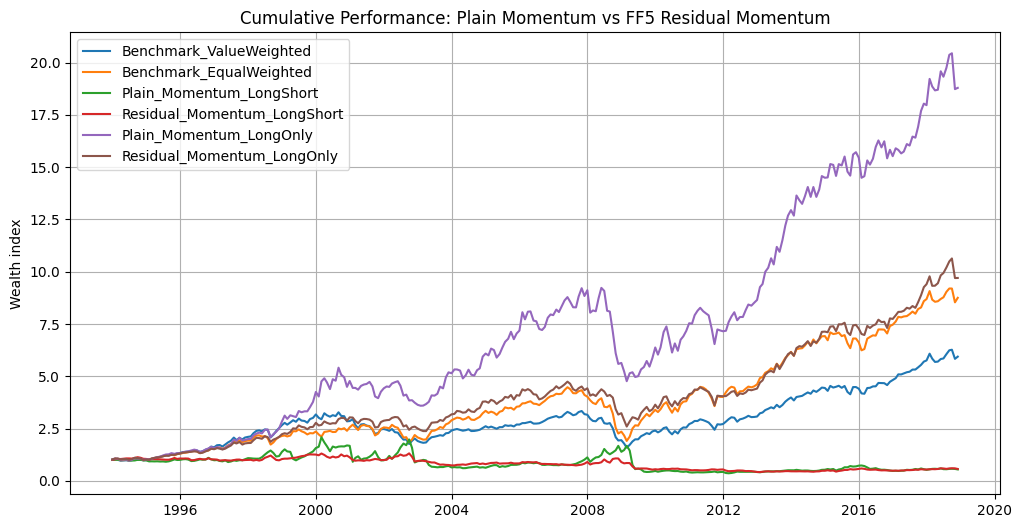

In [22]:
residual_comparison_wealth = (1 + residual_comparison_returns).cumprod()

plt.figure(figsize=(12, 6))

for column in residual_comparison_wealth.columns:
    plt.plot(
        residual_comparison_wealth.index,
        residual_comparison_wealth[column],
        label=column
    )

plt.title("Cumulative Performance: Plain Momentum vs FF5 Residual Momentum")
plt.ylabel("Wealth index")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.show()

**3.5.2 Long-short cumulative performance only**

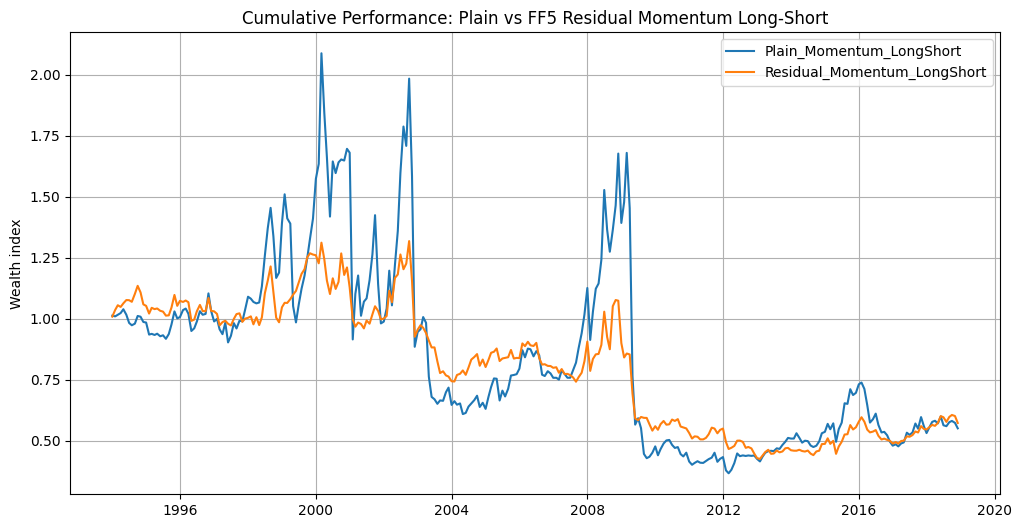

In [23]:
longshort_comparison_returns = residual_comparison_returns[
    [
        "Plain_Momentum_LongShort",
        "Residual_Momentum_LongShort"
    ]
]

longshort_comparison_wealth = (1 + longshort_comparison_returns).cumprod()

plt.figure(figsize=(12, 6))

for column in longshort_comparison_wealth.columns:
    plt.plot(
        longshort_comparison_wealth.index,
        longshort_comparison_wealth[column],
        label=column
    )

plt.title("Cumulative Performance: Plain vs FF5 Residual Momentum Long-Short")
plt.ylabel("Wealth index")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.show()

**3.5.3 Drawdown comparison: Plain vs Residual long-short**

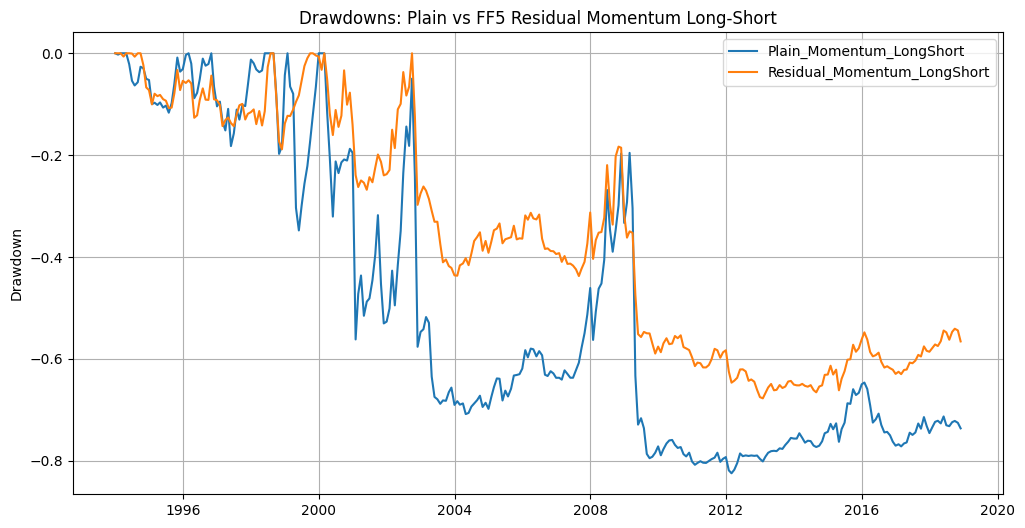

In [24]:
longshort_drawdowns = pd.DataFrame({
    column: compute_drawdown(longshort_comparison_returns[column])
    for column in longshort_comparison_returns.columns
})

plt.figure(figsize=(12, 6))

for column in longshort_drawdowns.columns:
    plt.plot(
        longshort_drawdowns.index,
        longshort_drawdowns[column],
        label=column
    )

plt.title("Drawdowns: Plain vs FF5 Residual Momentum Long-Short")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.show()

# **4. VOLATILITY TARGETED MOMENTUM**

**4.1 Volatility Targeting Methodology**

In [25]:
VOL_TARGET_ANNUAL = 0.10
VOL_TARGET_WINDOW = 6
VOL_TARGET_MAX_LEVERAGE = 2.0

print("Annual target volatility:", VOL_TARGET_ANNUAL)
print("Volatility estimation window:", VOL_TARGET_WINDOW)
print("Maximum leverage:", VOL_TARGET_MAX_LEVERAGE)

Annual target volatility: 0.1
Volatility estimation window: 6
Maximum leverage: 2.0


**4.2 Standard vol-targeted momentum**

In [26]:
def apply_volatility_targeting(
    strategy_return,
    target_vol_annual=0.10,
    vol_window=6,
    max_leverage=2.0
):
    """
    Apply volatility targeting to a monthly strategy return series.

    Scaling rule:
        scaling_t = target_vol / realised_vol_{t-1}

    The realised volatility is estimated using a trailing window and annualised.
    The scaling factor is capped to avoid excessive leverage.
    """
    strategy_return = strategy_return.copy().dropna()

    realised_volatility = (
        strategy_return
        .rolling(window=vol_window, min_periods=vol_window)
        .std()
        * np.sqrt(12)
    )

    scaling_factor = target_vol_annual / realised_volatility.shift(1)
    scaling_factor = scaling_factor.clip(lower=0, upper=max_leverage)

    voltarget_return = scaling_factor * strategy_return

    output = pd.DataFrame({
        "Plain_Momentum_LongShort": strategy_return,
        "Plain_Momentum_LongShort_VolTarget": voltarget_return,
        "Plain_Momentum_RealisedVol_6M": realised_volatility,
        "Plain_Momentum_VolTarget_Scaling": scaling_factor
    })

    return output


plain_voltarget_returns = apply_volatility_targeting(
    strategy_return=plain_momentum_returns["Plain_Momentum_LongShort"],
    target_vol_annual=VOL_TARGET_ANNUAL,
    vol_window=VOL_TARGET_WINDOW,
    max_leverage=VOL_TARGET_MAX_LEVERAGE
)

print("Vol-targeted momentum sample period:",
      plain_voltarget_returns["Plain_Momentum_LongShort_VolTarget"].dropna().index.min(),
      "to",
      plain_voltarget_returns["Plain_Momentum_LongShort_VolTarget"].dropna().index.max())

print("Number of valid vol-targeted observations:",
      plain_voltarget_returns["Plain_Momentum_LongShort_VolTarget"].notna().sum())

plain_voltarget_returns.head(15)

Vol-targeted momentum sample period: 1992-06-30 00:00:00 to 2018-11-30 00:00:00
Number of valid vol-targeted observations: 318


,Plain_Momentum_LongShort,Plain_Momentum_LongShort_VolTarget,Plain_Momentum_RealisedVol_6M,Plain_Momentum_VolTarget_Scaling
date,,,,
1991-12-31,0.074801,NaN,NaN,NaN
1992-01-31,-0.049519,NaN,NaN,NaN
1992-02-28,0.005741,NaN,NaN,NaN
1992-03-31,0.000973,NaN,NaN,NaN
1992-04-30,-0.073524,NaN,NaN,NaN
1992-05-29,-0.020584,NaN,0.178445,NaN
1992-06-30,-0.003545,-0.001987,0.109982,0.560396
1992-07-31,-0.021613,-0.019651,0.100778,0.909239
1992-08-31,-0.019990,-0.019836,0.091948,0.992281


**4.2.1 Plot volatility-targeting scaling factor**

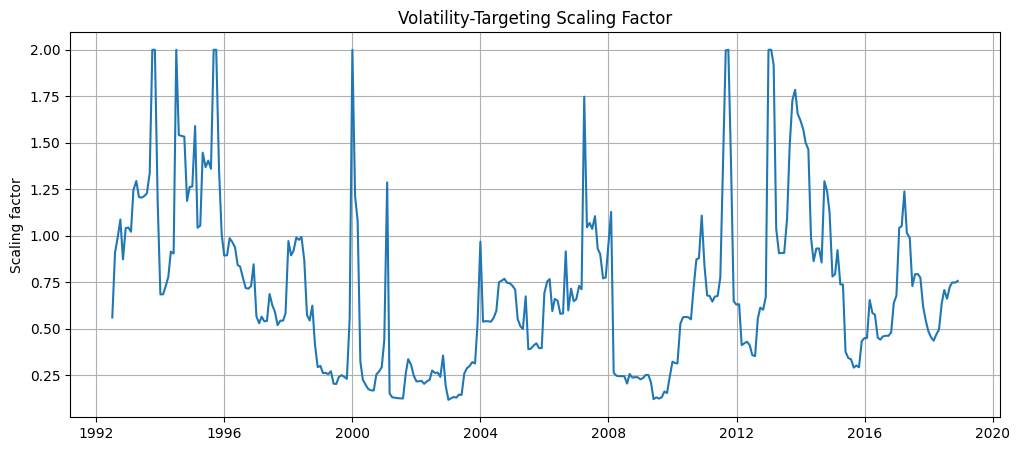

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    plain_voltarget_returns.index,
    plain_voltarget_returns["Plain_Momentum_VolTarget_Scaling"]
)

plt.title("Volatility-Targeting Scaling Factor")
plt.ylabel("Scaling factor")
plt.xlabel("")
plt.grid(True)
plt.show()

**4.3 Plain momentum vs volatility-targeted momentum**

The volatility-targeted strategy is compared with the unscaled plain momentum strategy over the same common sample period. The key question is whether volatility targeting reduces volatility, drawdowns and worst monthly losses relative to the plain long-short momentum baseline.

In [28]:
voltarget_comparison_returns = pd.concat(
    [
        benchmark_returns["Benchmark_ValueWeighted"],
        benchmark_returns["Benchmark_EqualWeighted"],
        plain_voltarget_returns["Plain_Momentum_LongShort"],
        plain_voltarget_returns["Plain_Momentum_LongShort_VolTarget"]
    ],
    axis=1
).dropna()

voltarget_comparison_performance = compute_performance_summary(
    voltarget_comparison_returns,
    benchmark_column="Benchmark_ValueWeighted"
)

print("Vol-target comparison sample period:",
      voltarget_comparison_returns.index.min(),
      "to",
      voltarget_comparison_returns.index.max())

print("Number of observations:",
      len(voltarget_comparison_returns))

voltarget_comparison_performance

Vol-target comparison sample period: 1992-06-30 00:00:00 to 2018-11-30 00:00:00
Number of observations: 318


,Annualized Mean Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Worst Month,Correlation with Benchmark
Strategy,,,,,,,
Benchmark_ValueWeighted,0.081290,0.073848,0.139387,0.583196,-0.524249,-0.169311,NaN
Benchmark_EqualWeighted,0.101139,0.092383,0.157024,0.644100,-0.573088,-0.210142,0.943037
Plain_Momentum_LongShort,0.032034,-0.015291,0.287947,0.111249,-0.824713,-0.473027,-0.388210
Plain_Momentum_LongShort_VolTarget,0.034740,0.012733,0.187870,0.184914,-0.653149,-0.586243,-0.190020


**4.4 Plain momentum vs volatility-targeted crash risk comparison**

To evaluate whether volatility targeting mitigates momentum crashes, I compare maximum drawdown, worst monthly return, worst 3-month compounded return and annualized volatility. These measures focus directly on downside risk rather than only on average performance.

In [29]:
def compute_worst_rolling_return(return_series, window=3):
    """
    Compute the worst compounded rolling return over a given window.
    """
    rolling_return = (
        (1 + return_series)
        .rolling(window=window)
        .apply(np.prod, raw=True)
        - 1
    )
    return rolling_return.min()


voltarget_crash_summary = pd.DataFrame({
    "Max Drawdown": {
        column: compute_drawdown(voltarget_comparison_returns[column]).min()
        for column in voltarget_comparison_returns.columns
    },
    "Worst Month": {
        column: voltarget_comparison_returns[column].min()
        for column in voltarget_comparison_returns.columns
    },
    "Worst 3M Return": {
        column: compute_worst_rolling_return(
            voltarget_comparison_returns[column],
            window=3
        )
        for column in voltarget_comparison_returns.columns
    },
    "Annualized Volatility": {
        column: voltarget_comparison_returns[column].std() * np.sqrt(12)
        for column in voltarget_comparison_returns.columns
    }
})

voltarget_crash_summary

,Max Drawdown,Worst Month,Worst 3M Return,Annualized Volatility
Benchmark_ValueWeighted,-0.524249,-0.169311,-0.300743,0.139387
Benchmark_EqualWeighted,-0.573088,-0.210142,-0.373468,0.157024
Plain_Momentum_LongShort,-0.824713,-0.473027,-0.663319,0.287947
Plain_Momentum_LongShort_VolTarget,-0.653149,-0.586243,-0.584422,0.187870


Volatility targeting improves several risk measures relative to plain momentum. In particular, it reduces annualized volatility, maximum drawdown and the worst 3-month return, while improving the Sharpe ratio and the compounded annual growth rate. However, the worst single monthly return is more severe for the volatility-targeted strategy. This may occur because the volatility forecast is lagged: if a sudden crash occurs after a low-volatility period, the scaling factor may still be high and can amplify the one-month loss.

**4.5 No leverage crash-protected version**

Because the leveraged volatility-targeted strategy may amplify sudden crashes when the lagged volatility forecast is low, I also report a no-leverage robustness version with the scaling factor capped at 1.0.

In [30]:
plain_voltarget_noleverage_returns = apply_volatility_targeting(
    strategy_return=plain_momentum_returns["Plain_Momentum_LongShort"],
    target_vol_annual=VOL_TARGET_ANNUAL,
    vol_window=VOL_TARGET_WINDOW,
    max_leverage=1.0
)

plain_voltarget_noleverage_returns = plain_voltarget_noleverage_returns.rename(
    columns={
        "Plain_Momentum_LongShort_VolTarget": "Plain_Momentum_LongShort_VolTarget_NoLeverage",
        "Plain_Momentum_RealisedVol_6M": "Plain_Momentum_RealisedVol_6M_NoLeverage",
        "Plain_Momentum_VolTarget_Scaling": "Plain_Momentum_VolTarget_Scaling_NoLeverage"
    }
)

print("No-leverage vol-targeted sample period:",
      plain_voltarget_noleverage_returns["Plain_Momentum_LongShort_VolTarget_NoLeverage"].dropna().index.min(),
      "to",
      plain_voltarget_noleverage_returns["Plain_Momentum_LongShort_VolTarget_NoLeverage"].dropna().index.max())

print("Number of valid no-leverage vol-targeted observations:",
      plain_voltarget_noleverage_returns["Plain_Momentum_LongShort_VolTarget_NoLeverage"].notna().sum())

plain_voltarget_noleverage_returns.head(15)

No-leverage vol-targeted sample period: 1992-06-30 00:00:00 to 2018-11-30 00:00:00
Number of valid no-leverage vol-targeted observations: 318


,Plain_Momentum_LongShort,Plain_Momentum_LongShort_VolTarget_NoLeverage,Plain_Momentum_RealisedVol_6M_NoLeverage,Plain_Momentum_VolTarget_Scaling_NoLeverage
date,,,,
1991-12-31,0.074801,NaN,NaN,NaN
1992-01-31,-0.049519,NaN,NaN,NaN
1992-02-28,0.005741,NaN,NaN,NaN
1992-03-31,0.000973,NaN,NaN,NaN
1992-04-30,-0.073524,NaN,NaN,NaN
1992-05-29,-0.020584,NaN,0.178445,NaN
1992-06-30,-0.003545,-0.001987,0.109982,0.560396
1992-07-31,-0.021613,-0.019651,0.100778,0.909239
1992-08-31,-0.019990,-0.019836,0.091948,0.992281


**4.6 Crash-risk summary**

In [31]:
voltarget_robustness_common_index = (
    benchmark_returns.index
    .intersection(plain_momentum_returns.index)
    .intersection(plain_voltarget_returns.index)
    .intersection(plain_voltarget_noleverage_returns.index)
)

voltarget_robustness_returns = pd.DataFrame(index=voltarget_robustness_common_index)

voltarget_robustness_returns["Benchmark_ValueWeighted"] = (
    benchmark_returns
    .loc[voltarget_robustness_common_index, "Benchmark_ValueWeighted"]
)

voltarget_robustness_returns["Plain_Momentum_LongShort"] = (
    plain_momentum_returns
    .loc[voltarget_robustness_common_index, "Plain_Momentum_LongShort"]
)

voltarget_robustness_returns["Plain_Momentum_LongShort_VolTarget"] = (
    plain_voltarget_returns
    .loc[voltarget_robustness_common_index, "Plain_Momentum_LongShort_VolTarget"]
)

voltarget_robustness_returns["Plain_Momentum_LongShort_VolTarget_NoLeverage"] = (
    plain_voltarget_noleverage_returns
    .loc[voltarget_robustness_common_index, "Plain_Momentum_LongShort_VolTarget_NoLeverage"]
)

voltarget_robustness_returns = voltarget_robustness_returns.dropna()

print("Volatility-targeting robustness sample period:",
      voltarget_robustness_returns.index.min(),
      "to",
      voltarget_robustness_returns.index.max())

print("Number of observations:",
      len(voltarget_robustness_returns))

voltarget_robustness_returns.head()

Volatility-targeting robustness sample period: 1992-06-30 00:00:00 to 2018-11-30 00:00:00
Number of observations: 318


,Benchmark_ValueWeighted,Plain_Momentum_LongShort,Plain_Momentum_LongShort_VolTarget,Plain_Momentum_LongShort_VolTarget_NoLeverage
1992-06-30,-0.017382,-0.003545,-0.001987,-0.001987
1992-07-31,0.039793,-0.021613,-0.019651,-0.019651
1992-08-31,-0.023990,-0.019990,-0.019836,-0.019836
1992-09-30,0.009066,0.028421,0.030909,0.028421
1992-10-30,0.002126,0.041669,0.036371,0.036371


In [32]:
voltarget_robustness_crash_summary = pd.DataFrame({
    "Max Drawdown": {
        column: compute_drawdown(voltarget_robustness_returns[column]).min()
        for column in voltarget_robustness_returns.columns
    },
    "Worst Month": {
        column: voltarget_robustness_returns[column].min()
        for column in voltarget_robustness_returns.columns
    },
    "Worst 3M Return": {
        column: compute_worst_rolling_return(
            voltarget_robustness_returns[column],
            window=3
        )
        for column in voltarget_robustness_returns.columns
    },
    "Annualized Volatility": {
        column: voltarget_robustness_returns[column].std() * np.sqrt(12)
        for column in voltarget_robustness_returns.columns
    }
})

voltarget_robustness_crash_summary

,Max Drawdown,Worst Month,Worst 3M Return,Annualized Volatility
Benchmark_ValueWeighted,-0.524249,-0.169311,-0.300743,0.139387
Plain_Momentum_LongShort,-0.824713,-0.473027,-0.663319,0.287947
Plain_Momentum_LongShort_VolTarget,-0.653149,-0.586243,-0.584422,0.187870
Plain_Momentum_LongShort_VolTarget_NoLeverage,-0.543610,-0.455573,-0.453178,0.158113


**4.6.1 Drawdowns with no-leverage version**

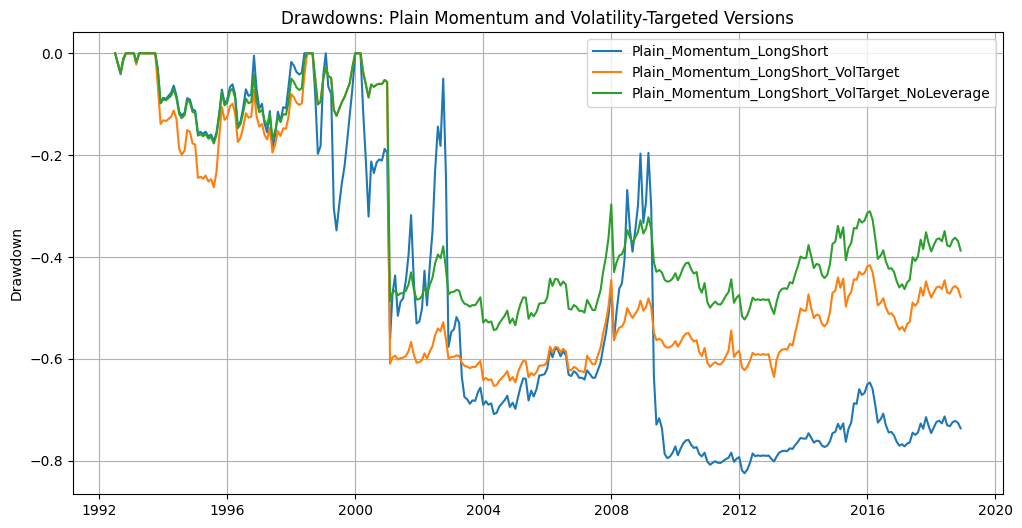

In [33]:
voltarget_robustness_drawdowns = pd.DataFrame({
    column: compute_drawdown(voltarget_robustness_returns[column])
    for column in voltarget_robustness_returns.columns
})

plt.figure(figsize=(12, 6))

for column in [
    "Plain_Momentum_LongShort",
    "Plain_Momentum_LongShort_VolTarget",
    "Plain_Momentum_LongShort_VolTarget_NoLeverage"
]:
    plt.plot(
        voltarget_robustness_drawdowns.index,
        voltarget_robustness_drawdowns[column],
        label=column
    )

plt.title("Drawdowns: Plain Momentum and Volatility-Targeted Versions")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.show()

The standard volatility-targeted strategy with a leverage cap of 2.0 improves the compounded return, Sharpe ratio, volatility and maximum drawdown relative to plain momentum. However, it also produces a worse single-month loss. The diagnostic analysis shows that this occurs when the lagged volatility estimate is relatively low and the scaling factor is above one, amplifying a sudden negative momentum month.

For this reason, I also consider a no-leverage volatility-targeted version, where the scaling factor is capped at 1.0. This version is more conservative and appears more consistent with the objective of crash protection. It reduces volatility, maximum drawdown, worst monthly loss and worst 3-month return relative to plain momentum.

# **5. COMBINED STRATEGY**

As an additional refinement, I combine the two previous improvements. The signal is based on FF5 residual momentum, while the long-short portfolio return is scaled using the no-leverage volatility-targeting rule.

This combined strategy is designed to address both weaknesses of plain momentum: residualisation reduces the dependence on systematic factor exposures, while no-leverage volatility targeting aims to mitigate crash risk without increasing exposure above 100%.

**5.1 Residual momentum + no-leverage volatility targeting**

In [34]:
# Apply no-leverage volatility targeting to the FF5 residual momentum long-short strategy.
combined_residual_voltarget_returns = apply_volatility_targeting(
    strategy_return=residual_momentum_returns["Residual_Momentum_LongShort"],
    target_vol_annual=VOL_TARGET_ANNUAL,
    vol_window=VOL_TARGET_WINDOW,
    max_leverage=1.0
)

# Rename columns explicitly.
# The apply_volatility_targeting function may return column names based on
# "Plain_Momentum_LongShort", so we standardize them here.
combined_residual_voltarget_returns = combined_residual_voltarget_returns.rename(
    columns={
        "Plain_Momentum_LongShort": "Residual_Momentum_LongShort",
        "Plain_Momentum_LongShort_VolTarget": "Combined_Residual_Momentum_VolTarget_NoLeverage",
        "Plain_Momentum_RealisedVol_6M": "Combined_Residual_Momentum_RealisedVol_6M",
        "Plain_Momentum_VolTarget_Scaling": "Combined_Residual_Momentum_VolTarget_Scaling",

        "Residual_Momentum_LongShort_VolTarget": "Combined_Residual_Momentum_VolTarget_NoLeverage",
        "Residual_Momentum_RealisedVol_6M": "Combined_Residual_Momentum_RealisedVol_6M",
        "Residual_Momentum_VolTarget_Scaling": "Combined_Residual_Momentum_VolTarget_Scaling"
    }
)

# Safety check: verify that the expected column exists.
combined_col = "Combined_Residual_Momentum_VolTarget_NoLeverage"

if combined_col not in combined_residual_voltarget_returns.columns:
    raise KeyError(
        f"Expected column {combined_col} was not created. "
        "Check the output columns of apply_volatility_targeting()."
    )

print("Combined strategy sample period:",
      combined_residual_voltarget_returns[combined_col].dropna().index.min(),
      "to",
      combined_residual_voltarget_returns[combined_col].dropna().index.max())

print("Number of valid combined strategy observations:",
      combined_residual_voltarget_returns[combined_col].notna().sum())

combined_residual_voltarget_returns.head(15)

Combined strategy sample period: 1994-06-30 00:00:00 to 2018-11-30 00:00:00
Number of valid combined strategy observations: 294


,Residual_Momentum_LongShort,Combined_Residual_Momentum_VolTarget_NoLeverage,Combined_Residual_Momentum_RealisedVol_6M,Combined_Residual_Momentum_VolTarget_Scaling
date,,,,
1993-12-31,0.008282,NaN,NaN,NaN
1994-01-31,0.027119,NaN,NaN,NaN
1994-02-28,0.018607,NaN,NaN,NaN
1994-03-31,-0.006473,NaN,NaN,NaN
1994-04-29,0.014006,NaN,NaN,NaN
1994-05-31,0.012676,NaN,0.038915,NaN
1994-06-30,-0.000527,-0.000527,0.042923,1.000000
1994-07-29,-0.006196,-0.006196,0.038324,1.000000
1994-08-31,0.030349,0.030349,0.049917,1.000000


**5.2 Final comparison on common sample**

In [35]:
final_strategy_returns = pd.concat(
    [
        benchmark_returns["Benchmark_ValueWeighted"],
        benchmark_returns["Benchmark_EqualWeighted"],
        plain_momentum_returns["Plain_Momentum_LongShort"],
        residual_momentum_returns["Residual_Momentum_LongShort"],
        plain_voltarget_noleverage_returns["Plain_Momentum_LongShort_VolTarget_NoLeverage"],
        combined_residual_voltarget_returns["Combined_Residual_Momentum_VolTarget_NoLeverage"]
    ],
    axis=1
).dropna()

final_strategy_performance = compute_performance_summary(
    final_strategy_returns,
    benchmark_column="Benchmark_ValueWeighted"
)

print("Final comparison sample period:",
      final_strategy_returns.index.min(),
      "to",
      final_strategy_returns.index.max())

print("Number of observations:",
      len(final_strategy_returns))

final_strategy_performance

Final comparison sample period: 1994-06-30 00:00:00 to 2018-11-30 00:00:00
Number of observations: 294


,Annualized Mean Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Worst Month,Correlation with Benchmark
Strategy,,,,,,,
Benchmark_ValueWeighted,0.083846,0.075967,0.143376,0.584795,-0.524249,-0.169311,NaN
Benchmark_EqualWeighted,0.102023,0.092531,0.161662,0.631086,-0.573088,-0.210142,0.942725
Plain_Momentum_LongShort,0.025868,-0.024727,0.298191,0.086749,-0.824713,-0.473027,-0.395504
Residual_Momentum_LongShort,-0.013405,-0.025450,0.155594,-0.086156,-0.677583,-0.198306,-0.326586
Plain_Momentum_LongShort_VolTarget_NoLeverage,0.020367,0.005397,0.162124,0.125624,-0.543610,-0.455573,-0.229659
Combined_Residual_Momentum_VolTarget_NoLeverage,0.001716,-0.003723,0.104395,0.016433,-0.427856,-0.094786,-0.283002


**5.3 Final cumulative performance and drawdowns**

In [36]:
final_crash_summary = pd.DataFrame({
    "Max Drawdown": {
        column: compute_drawdown(final_strategy_returns[column]).min()
        for column in final_strategy_returns.columns
    },
    "Worst Month": {
        column: final_strategy_returns[column].min()
        for column in final_strategy_returns.columns
    },
    "Worst 3M Return": {
        column: compute_worst_rolling_return(
            final_strategy_returns[column],
            window=3
        )
        for column in final_strategy_returns.columns
    },
    "Annualized Volatility": {
        column: final_strategy_returns[column].std() * np.sqrt(12)
        for column in final_strategy_returns.columns
    }
})

final_crash_summary

,Max Drawdown,Worst Month,Worst 3M Return,Annualized Volatility
Benchmark_ValueWeighted,-0.524249,-0.169311,-0.300743,0.143376
Benchmark_EqualWeighted,-0.573088,-0.210142,-0.373468,0.161662
Plain_Momentum_LongShort,-0.824713,-0.473027,-0.663319,0.298191
Residual_Momentum_LongShort,-0.677583,-0.198306,-0.315957,0.155594
Plain_Momentum_LongShort_VolTarget_NoLeverage,-0.543610,-0.455573,-0.453178,0.162124
Combined_Residual_Momentum_VolTarget_NoLeverage,-0.427856,-0.094786,-0.131362,0.104395


# **6. FACTOR EXPOSURE ANALYSIS**

In [37]:
ff5_for_regression = ff5_factors_aligned.loc[
    final_strategy_returns.index
].copy()

print("Regression factor sample period:",
      ff5_for_regression.index.min(),
      "to",
      ff5_for_regression.index.max())

print("FF5 factor observations:", len(ff5_for_regression))

ff5_for_regression.head()

Regression factor sample period: 1994-06-30 00:00:00 to 2018-11-30 00:00:00
FF5 factor observations: 294


,MKT_RF,SMB,HML,RMW,CMA,RF
1994-06-30,-0.0304,-0.0052,0.0177,0.0105,0.0150,0.0031
1994-07-29,0.0282,-0.0187,0.0061,-0.0066,0.0010,0.0028
1994-08-31,0.0402,0.0144,-0.0255,0.0098,-0.0152,0.0037
1994-09-30,-0.0228,0.0271,-0.0181,0.0056,0.0106,0.0037
1994-10-31,0.0135,-0.0222,-0.0166,0.0018,-0.0073,0.0038


**6.1 FF5 regressions on strategy returns**

In [38]:
def run_ff5_factor_regressions(
    strategy_returns,
    factors,
    factor_columns,
    rf_column="RF"
):
    """
    Run Fama-French 5-factor regressions for each strategy.

    For benchmark portfolios, excess returns are used.
    For long-short strategies, raw returns are used because they are
    zero-investment portfolios.
    """
    regression_records = []

    common_index = strategy_returns.index.intersection(factors.index)

    strategy_returns = strategy_returns.loc[common_index]
    factors = factors.loc[common_index]

    X = sm.add_constant(factors[factor_columns])

    for strategy in strategy_returns.columns:
        y = strategy_returns[strategy].copy()

        # Funded benchmark returns are converted to excess returns.
        # Long-short strategies are kept as raw zero-investment returns.
        if "Benchmark" in strategy:
            y = y - factors[rf_column]

        regression_data = pd.concat(
            [y.rename("y"), X],
            axis=1
        ).dropna()

        y_reg = regression_data["y"]
        X_reg = regression_data.drop(columns="y")

        model = sm.OLS(y_reg, X_reg).fit()

        record = {
            "Strategy": strategy,
            "Alpha Monthly": model.params["const"],
            "Alpha Annualized": model.params["const"] * 12,
            "Alpha t-stat": model.tvalues["const"],
            "R-squared": model.rsquared
        }

        for factor in factor_columns:
            record[f"Beta {factor}"] = model.params[factor]
            record[f"t-stat {factor}"] = model.tvalues[factor]

        regression_records.append(record)

    return pd.DataFrame(regression_records).set_index("Strategy")


ff5_factor_exposure = run_ff5_factor_regressions(
    strategy_returns=final_strategy_returns,
    factors=ff5_for_regression,
    factor_columns=ff5_factor_columns,
    rf_column="RF"
)

ff5_factor_exposure

,Alpha Monthly,Alpha Annualized,Alpha t-stat,R-squared,Beta MKT_RF,t-stat MKT_RF,Beta SMB,t-stat SMB,Beta HML,t-stat HML,Beta RMW,t-stat RMW,Beta CMA,t-stat CMA
Strategy,,,,,,,,,,,,,,
Benchmark_ValueWeighted,-0.002002,-0.024019,-9.889694,0.993836,1.007314,186.462399,-0.157005,-22.036629,0.032950,3.561218,0.071787,7.442729,0.034677,2.642143
Benchmark_EqualWeighted,-0.002465,-0.029583,-3.247305,0.931909,1.112688,54.910427,0.080603,3.016050,0.226686,6.531667,0.168700,4.662887,0.148660,3.019725
Plain_Momentum_LongShort,0.005018,0.060219,1.053174,0.210564,-0.649068,-5.103374,0.309398,1.844542,-0.913743,-4.194781,0.702294,3.092756,0.183337,0.593348
Residual_Momentum_LongShort,0.000995,0.011934,0.380986,0.129765,-0.338184,-4.853578,0.175584,1.910724,-0.130158,-1.090680,0.221689,1.782021,-0.253961,-1.500270
Plain_Momentum_LongShort_VolTarget_NoLeverage,0.003288,0.039450,1.171635,0.073891,-0.229677,-3.066613,0.061493,0.622550,-0.345690,-2.694927,0.025832,0.193180,0.182274,1.001751
Combined_Residual_Momentum_VolTarget_NoLeverage,0.001120,0.013437,0.632024,0.109586,-0.185129,-3.914869,0.130066,2.085511,-0.146868,-1.813384,0.173626,2.056449,-0.099035,-0.862033


**6.1.2 Compact exposure table**

In [39]:
compact_factor_exposure = ff5_factor_exposure[
    [
        "Alpha Annualized",
        "Alpha t-stat",
        "Beta MKT_RF",
        "Beta SMB",
        "Beta HML",
        "Beta RMW",
        "Beta CMA",
        "R-squared"
    ]
]

compact_factor_exposure

,Alpha Annualized,Alpha t-stat,Beta MKT_RF,Beta SMB,Beta HML,Beta RMW,Beta CMA,R-squared
Strategy,,,,,,,,
Benchmark_ValueWeighted,-0.024019,-9.889694,1.007314,-0.157005,0.032950,0.071787,0.034677,0.993836
Benchmark_EqualWeighted,-0.029583,-3.247305,1.112688,0.080603,0.226686,0.168700,0.148660,0.931909
Plain_Momentum_LongShort,0.060219,1.053174,-0.649068,0.309398,-0.913743,0.702294,0.183337,0.210564
Residual_Momentum_LongShort,0.011934,0.380986,-0.338184,0.175584,-0.130158,0.221689,-0.253961,0.129765
Plain_Momentum_LongShort_VolTarget_NoLeverage,0.039450,1.171635,-0.229677,0.061493,-0.345690,0.025832,0.182274,0.073891
Combined_Residual_Momentum_VolTarget_NoLeverage,0.013437,0.632024,-0.185129,0.130066,-0.146868,0.173626,-0.099035,0.109586


**6.2 Factor beta and R-squared comparison**

The FF5 regressions show that the plain long-short momentum strategy has meaningful exposure to systematic factors. In particular, it has a negative market beta and sizeable exposures to HML and RMW. This confirms that the plain momentum portfolio is not fully factor-neutral.

The FF5 residual momentum strategy reduces several of these exposures. Its market beta, HML beta and RMW beta are lower in absolute value than those of the plain momentum strategy, and its FF5 R-squared is also lower. This suggests that residualisation helps reduce the dependence of the momentum strategy on common systematic factors, although it does not eliminate factor exposure completely.

The combined residual momentum and no-leverage volatility-targeted strategy has one of the lowest market betas and a relatively low R-squared. It also displays the lowest volatility and the mildest crash-risk measures among the momentum strategies. However, the alpha t-statistics are not large, so the evidence should not be interpreted as strong abnormal performance. Rather, the main improvement is in risk reduction and crash mitigation.

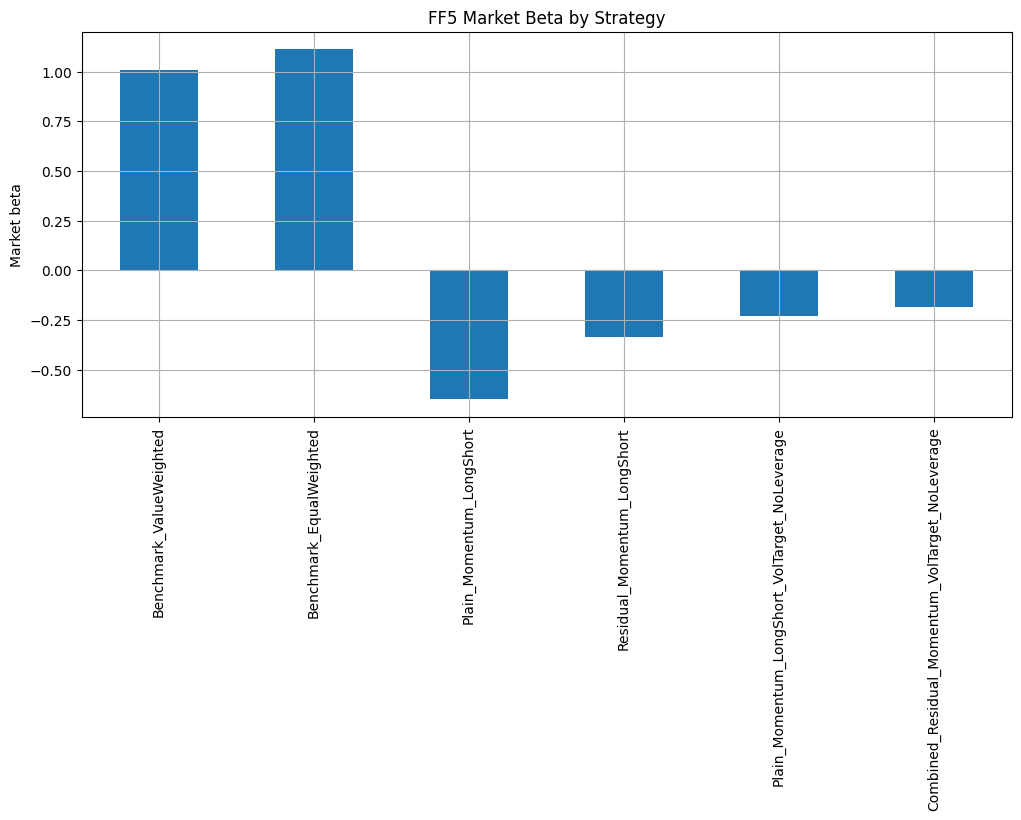

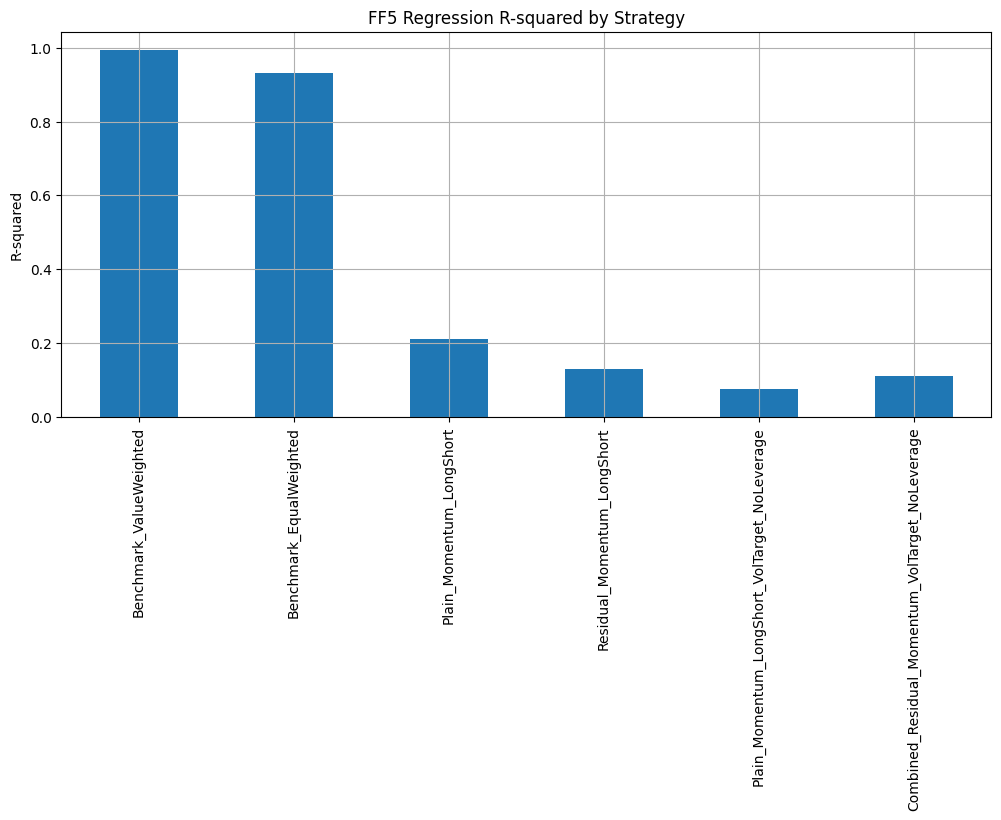

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

compact_factor_exposure["Beta MKT_RF"].plot(kind="bar", ax=ax)

plt.title("FF5 Market Beta by Strategy")
plt.ylabel("Market beta")
plt.xlabel("")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

compact_factor_exposure["R-squared"].plot(kind="bar", ax=ax)

plt.title("FF5 Regression R-squared by Strategy")
plt.ylabel("R-squared")
plt.xlabel("")
plt.grid(True)
plt.show()

# **7. FINAL SUMMARY OF RESULTS**

This section summarizes the main empirical findings. The comparison focuses on the common sample period in which all strategies are available. The table reports performance, crash-risk indicators and selected FF5 exposure measures.

The goal is not only to identify the strategy with the highest return, but also to evaluate whether the proposed refinements reduce the two weaknesses of plain momentum: exposure to systematic risk factors and momentum crashes.

**7.1 Final summary table**

In [41]:
final_summary_table = pd.DataFrame(index=final_strategy_returns.columns)

# Performance metrics
final_summary_table["Annualized Mean Return"] = final_strategy_performance["Annualized Mean Return"]
final_summary_table["CAGR"] = final_strategy_performance["CAGR"]
final_summary_table["Annualized Volatility"] = final_strategy_performance["Annualized Volatility"]
final_summary_table["Sharpe Ratio"] = final_strategy_performance["Sharpe Ratio"]

# Crash-risk metrics
final_summary_table["Max Drawdown"] = final_crash_summary["Max Drawdown"]
final_summary_table["Worst Month"] = final_crash_summary["Worst Month"]
final_summary_table["Worst 3M Return"] = final_crash_summary["Worst 3M Return"]

# Factor exposure metrics
final_summary_table["FF5 Alpha Annualized"] = compact_factor_exposure["Alpha Annualized"]
final_summary_table["FF5 Alpha t-stat"] = compact_factor_exposure["Alpha t-stat"]
final_summary_table["FF5 Market Beta"] = compact_factor_exposure["Beta MKT_RF"]
final_summary_table["FF5 R-squared"] = compact_factor_exposure["R-squared"]


In [42]:
strategy_labels = {
    "Benchmark_ValueWeighted": "VW Benchmark",
    "Benchmark_EqualWeighted": "EW Benchmark",
    "Plain_Momentum_LongShort": "Plain MOM",
    "Residual_Momentum_LongShort": "FF5 Residual MOM",
    "Plain_Momentum_LongShort_VolTarget_NoLeverage": "Plain MOM VT No-Lev",
    "Combined_Residual_Momentum_VolTarget_NoLeverage": "Combined Residual + VT"
}

final_summary_table_presentation = final_summary_table.rename(
    index=strategy_labels
)


In [43]:
percentage_columns = [
    "Annualized Mean Return",
    "CAGR",
    "Annualized Volatility",
    "Max Drawdown",
    "Worst Month",
    "Worst 3M Return",
    "FF5 Alpha Annualized"
]

styled_final_summary = final_summary_table_presentation.style.format({
    "Annualized Mean Return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Max Drawdown": "{:.2%}",
    "Worst Month": "{:.2%}",
    "Worst 3M Return": "{:.2%}",
    "FF5 Alpha Annualized": "{:.2%}",
    "FF5 Alpha t-stat": "{:.2f}",
    "FF5 Market Beta": "{:.3f}",
    "FF5 R-squared": "{:.3f}"
})

styled_final_summary

,Annualized Mean Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Worst Month,Worst 3M Return,FF5 Alpha Annualized,FF5 Alpha t-stat,FF5 Market Beta,FF5 R-squared
VW Benchmark,8.38%,7.60%,14.34%,0.585,-52.42%,-16.93%,-30.07%,-2.40%,-9.89,1.007,0.994
EW Benchmark,10.20%,9.25%,16.17%,0.631,-57.31%,-21.01%,-37.35%,-2.96%,-3.25,1.113,0.932
Plain MOM,2.59%,-2.47%,29.82%,0.087,-82.47%,-47.30%,-66.33%,6.02%,1.05,-0.649,0.211
FF5 Residual MOM,-1.34%,-2.54%,15.56%,-0.086,-67.76%,-19.83%,-31.60%,1.19%,0.38,-0.338,0.130
Plain MOM VT No-Lev,2.04%,0.54%,16.21%,0.126,-54.36%,-45.56%,-45.32%,3.95%,1.17,-0.230,0.074
Combined Residual + VT,0.17%,-0.37%,10.44%,0.016,-42.79%,-9.48%,-13.14%,1.34%,0.63,-0.185,0.110


**7.2 Momentum-only summary**

In [44]:
momentum_strategy_order = [
    "Plain MOM",
    "FF5 Residual MOM",
    "Plain MOM VT No-Lev",
    "Combined Residual + VT"
]

momentum_summary_table = final_summary_table_presentation.loc[
    momentum_strategy_order
]

momentum_summary_table.style.format({
    "Annualized Mean Return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Max Drawdown": "{:.2%}",
    "Worst Month": "{:.2%}",
    "Worst 3M Return": "{:.2%}",
    "FF5 Alpha Annualized": "{:.2%}",
    "FF5 Alpha t-stat": "{:.2f}",
    "FF5 Market Beta": "{:.3f}",
    "FF5 R-squared": "{:.3f}"
})

,Annualized Mean Return,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Worst Month,Worst 3M Return,FF5 Alpha Annualized,FF5 Alpha t-stat,FF5 Market Beta,FF5 R-squared
Plain MOM,2.59%,-2.47%,29.82%,0.087,-82.47%,-47.30%,-66.33%,6.02%,1.05,-0.649,0.211
FF5 Residual MOM,-1.34%,-2.54%,15.56%,-0.086,-67.76%,-19.83%,-31.60%,1.19%,0.38,-0.338,0.130
Plain MOM VT No-Lev,2.04%,0.54%,16.21%,0.126,-54.36%,-45.56%,-45.32%,3.95%,1.17,-0.230,0.074
Combined Residual + VT,0.17%,-0.37%,10.44%,0.016,-42.79%,-9.48%,-13.14%,1.34%,0.63,-0.185,0.110


**7.3 Cumulative performance and drawdown plots**

**7.3.1 Summary plot of cumulative performance**

In [45]:
final_strategy_wealth = (1 + final_strategy_returns).cumprod()

final_strategy_drawdowns = pd.DataFrame({
    column: compute_drawdown(final_strategy_returns[column])
    for column in final_strategy_returns.columns
})

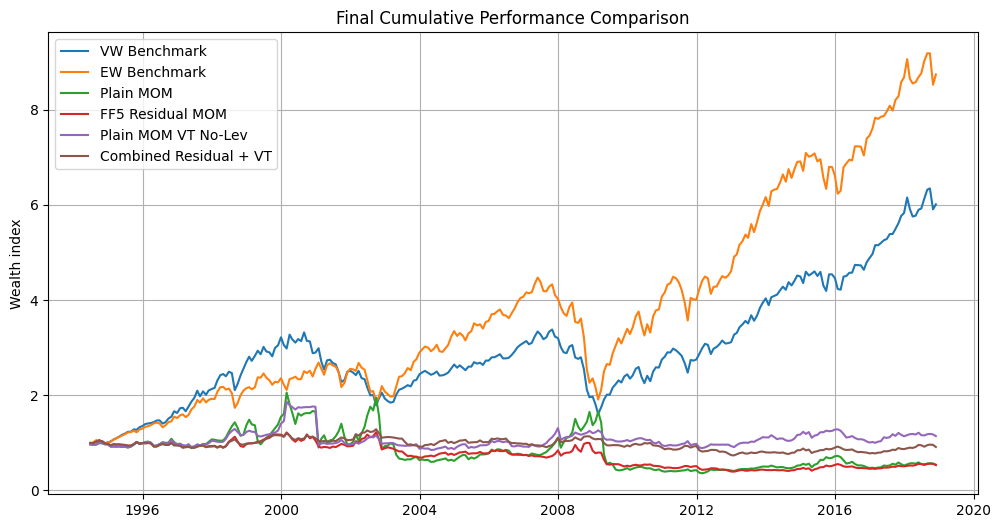

In [46]:
final_strategy_wealth_presentation = final_strategy_wealth.rename(
    columns=strategy_labels
)

plt.figure(figsize=(12, 6))

for column in final_strategy_wealth_presentation.columns:
    plt.plot(
        final_strategy_wealth_presentation.index,
        final_strategy_wealth_presentation[column],
        label=column
    )

plt.title("Final Cumulative Performance Comparison")
plt.ylabel("Wealth index")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.show()

**7.3.2 Summary plot of drawdowns**

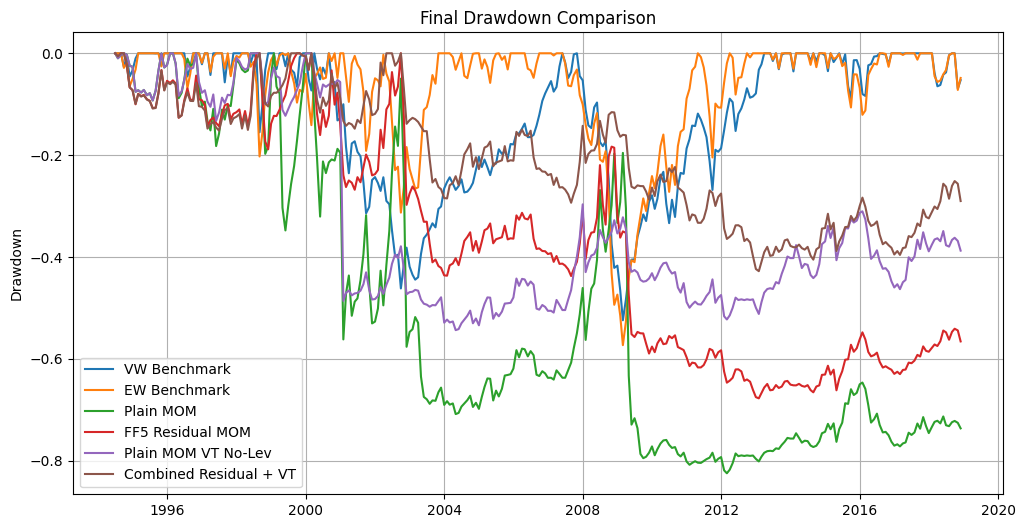

In [47]:
final_strategy_drawdowns_presentation = final_strategy_drawdowns.rename(
    columns=strategy_labels
)

plt.figure(figsize=(12, 6))

for column in final_strategy_drawdowns_presentation.columns:
    plt.plot(
        final_strategy_drawdowns_presentation.index,
        final_strategy_drawdowns_presentation[column],
        label=column
    )

plt.title("Final Drawdown Comparison")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.show()

**7.4 Final interpretation**

The final comparison shows that none of the momentum strategies dominates across all dimensions.

The plain long-short momentum strategy has weak compounded performance and the most severe crash profile, with the largest maximum drawdown and worst 3-month return. This confirms that the baseline strategy is exposed to substantial crash risk.

FF5 residual momentum reduces volatility, maximum drawdown, worst monthly loss and FF5 factor exposure relative to plain momentum. However, it does not improve average performance in this sample.

The no-leverage volatility-targeted version of plain momentum improves the compounded return and substantially reduces volatility and maximum drawdown. This suggests that volatility scaling is useful for mitigating momentum crashes, especially when the scaling factor is not allowed to exceed one.

The combined residual momentum and no-leverage volatility-targeted strategy has the most defensive profile among the momentum strategies. It has the lowest volatility, the lowest maximum drawdown, the mildest worst monthly loss and the mildest worst 3-month return. It also displays relatively low FF5 market beta and R-squared. However, its return performance is modest, and the FF5 alpha is not statistically strong.

Overall, the evidence suggests that the proposed refinements are more effective at reducing risk and crash exposure than at generating higher abnormal returns.

**8. CONCLUSION**

This project studies whether a plain cross-sectional momentum strategy can be improved by addressing two well-known weaknesses: exposure to systematic risk factors and momentum crashes.

The empirical analysis starts from a standard 12–1 cross-sectional momentum strategy on S&P 500 constituents. The data inspection shows that the raw price sheet contains stale or forward-filled prices for many inactive stocks. Therefore, the investable universe is reconstructed using the historical weights sheet, and a stock is considered eligible only when its lagged S&P 500 weight is positive.

The plain long-short momentum strategy displays a weak compounded performance and a severe crash profile. Over the common final sample, it has high volatility, a maximum drawdown of about -82%, and a worst 3-month return of about -66%. This confirms that the baseline strategy is exposed to substantial crash risk.

The FF5 residual momentum strategy reduces the exposure to systematic factors. Compared with plain momentum, it has a lower market beta in absolute value, lower exposure to HML and RMW, and a lower FF5 R-squared. It also reduces volatility and drawdown. However, it does not improve return performance in this sample.

The no-leverage volatility-targeted strategy improves the crash profile of plain momentum. By capping the scaling factor at 1.0, the strategy avoids increasing exposure after low-volatility periods. This version reduces volatility, maximum drawdown and worst 3-month losses relative to the plain momentum baseline.

The combined strategy, which applies no-leverage volatility targeting to FF5 residual momentum, has the most defensive profile among the momentum strategies. It achieves the lowest volatility, the mildest maximum drawdown, the mildest worst monthly return and the mildest worst 3-month return. It also has relatively low FF5 market beta and R-squared.

However, the combined strategy does not generate strong abnormal performance. Its return is modest and the FF5 alpha is not statistically strong. Therefore, the main empirical finding is not that the refined strategies dominate the benchmark in terms of return, but that they are more effective at reducing the two weaknesses of plain momentum: systematic factor exposure and crash risk.

Overall, the results suggest that residualisation and volatility targeting are useful risk-management refinements for momentum strategies, especially when the objective is to make the strategy more stable and less exposed to severe crashes.

******************************************************************************************
